In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  


In [2]:
from stericheight.data_handler import *
from stericheight.plotting_fns import PlottingFns
from stericheight.utils import Utils
from load_meop import MEOP
from region import Region
from composite import Composite
pfns = PlottingFns()

In [3]:
import gsw
import glob
import cartopy
import cmocean
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.optimize import root_scalar
from gsw import density


fname_spira = '../data/qc_profile_ds_2dbar.nc'
f140 = '../data/SOSE/Adelie_140E_*.nc'


In [4]:
sla = SLA(deg=0.25).da
sice = xr.open_dataset('../data/NSIDC/sice_processed.nc')
sice = sice.__xarray_dataarray_variable__
elevation_ = GEBCO(coarsen_factor=1).ds.elevation

In [5]:
ds140 = xr.open_mfdataset(glob.glob(f140))
ds140['year'] = ds140.time.dt.year
ds140['month'] = ds140.time.dt.month


In [6]:
ds140 = ds140.sel(YC=slice(-78,-66))

In [7]:
soses = ds140.SALT
soset = ds140.THETA

soses.load()
soset.load()

<xarray.DataArray 'THETA' (time: 803, Z: 52, YC: 242)> Size: 40MB
array([[[ 0.       ,  0.       ,  0.       , ..., -1.8616912,
         -1.862463 , -1.860784 ],
        [ 0.       ,  0.       ,  0.       , ..., -1.8616437,
         -1.8624245, -1.8607432],
        [ 0.       ,  0.       ,  0.       , ..., -1.8616333,
         -1.8624063, -1.8607298],
        ...,
        [ 0.       ,  0.       ,  0.       , ...,  0.       ,
          0.       ,  0.       ],
        [ 0.       ,  0.       ,  0.       , ...,  0.       ,
          0.       ,  0.       ],
        [ 0.       ,  0.       ,  0.       , ...,  0.       ,
          0.       ,  0.       ]],

       [[ 0.       ,  0.       ,  0.       , ..., -1.855345 ,
         -1.8553853, -1.8546016],
        [ 0.       ,  0.       ,  0.       , ..., -1.855099 ,
         -1.8553079, -1.8544496],
        [ 0.       ,  0.       ,  0.       , ..., -1.8551449,
         -1.8554336, -1.8545281],
...
        [ 0.       ,  0.       ,  0.       , ...,  0.       ,
          0.       ,  0.       ],
        [ 0.       ,  0.       ,  0.       , ...,  0.       ,
          0.       ,  0.       ],
        [ 0.       ,  0.       ,  0.       , ...,  0.       ,
          0.       ,  0.       ]],

       [[ 0.       ,  0.       ,  0.       , ..., -1.3701081,
         -1.3277123, -1.2959099],
        [ 0.       ,  0.       ,  0.       , ..., -1.3657215,
         -1.3242036, -1.2936279],
        [ 0.       ,  0.       ,  0.       , ..., -1.3584168,
         -1.3172029, -1.28888  ],
        ...,
        [ 0.       ,  0.       ,  0.       , ...,  0.       ,
          0.       ,  0.       ],
        [ 0.       ,  0.       ,  0.       , ...,  0.       ,
          0.       ,  0.       ],
        [ 0.       ,  0.       ,  0.       , ...,  0.       ,
          0.       ,  0.       ]]], shape=(803, 52, 242), dtype=float32)
Coordinates: (12/14)
  * time     (time) datetime64[ns] 6kB 2013-01-03T12:00:00 ... 2023-12-27T12:...
  * Z        (Z) float64 416B -2.1 -6.7 -12.15 ... -5e+03 -5.4e+03 -5.8e+03
  * YC       (YC) float64 2kB -77.98 -77.95 -77.91 ... -66.18 -66.11 -66.04
    XC       float64 8B 139.9
    XG       float64 8B 140.0
    iter     (time) int64 6kB 360 720 1080 1440 ... 288000 288360 288720 289080
    ...       ...
    rA       (YC) float64 2kB 1.488e+07 1.497e+07 ... 5.632e+07 5.662e+07
    Depth    (YC) float64 2kB 0.0 0.0 0.0 0.0 0.0 ... 342.0 170.0 190.0 190.0
    rAw      (YC) float64 2kB 1.488e+07 1.497e+07 ... 5.632e+07 5.662e+07
    drF      (Z) float64 416B 4.2 5.0 5.9 6.9 8.5 ... 400.0 400.0 400.0 400.0
    hFacC    (Z, YC) float64 101kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    hFacW    (Z, YC) float64 101kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
Attributes:
    standard_name:  THETA
    long_name:      Potential Temperature
    units:          degC

In [8]:
sosessf = soses.where(soses.Depth < 1000,drop=True)
sosetsf = soset.where(soset.Depth < 1000,drop=True)

In [9]:
sosessf = sosessf.where(sosessf>32,np.nan)
sosetsf = sosetsf.where(~(sosetsf == 0),np.nan)

In [10]:
def sanom(da):
    return da.groupby('time.month') - da.groupby('time.month').mean()

In [11]:
extent =[138, 150,-68,-64]
elevation = elevation_.sel(latitude = slice(extent[2], extent[3]), longitude = slice(extent[0],extent[1]))
mertz = Region('Mertz',extent)


In [12]:
# set up lines of constant density

def sig0range(tlims,slims):
    sig0_n = 100
    temprange = np.linspace(tlims[0],tlims[1],sig0_n)
    psalrange = np.linspace(slims[0],slims[1],sig0_n)

    sig0range = np.zeros((sig0_n,sig0_n))
    for i,t in enumerate(temprange):
        for j,s in enumerate(psalrange):
            sig0range[i,j]=gsw.sigma0(gsw.conversions.SA_from_SP(s,0,145,-67),gsw.CT_from_t(s,t,0))
    return temprange,psalrange,sig0range


In [13]:
ds = xr.open_dataset(fname_spira).swap_dims({'n_prof':'time'})
ds = ds.where(
    (ds.lon > extent[0]) &
    (ds.lon < extent[1]) &
    (ds.lat > -66) & #extent[2]) &
    (ds.lat < -65.5),drop=True#extent[3]), drop=True
)

In [14]:
meop=MEOP(extent=[138,150,-66,-65.5])#extent)
meop.load_profiles_for_spira()

  6%|▌         | 5/84 [00:00<00:06, 11.91it/s]

100%|██████████| 84/84 [00:10<00:00,  8.07it/s]


In [15]:
seals = meop.ds.sortby('time').sel(time=slice(ds.time[-1],pd.Timestamp(2025,1,1)))

# filter silly values
seals = seals.where(~((seals.psal < 30) | (seals.psal > 36)))

In [16]:
seals25 = seals.where(seals.pres < 25,drop=True)
seals300 = seals.where(seals.pres < 300,drop=True)

In [17]:
# make sure there is a value above 25dbar
keep = []
for t in seals.time:
    tmp25 = seals25.sel(time=t)
    tmp300 = seals300.sel(time=t)
    boo25 = np.any(~np.isnan(seals25.temp) & ~np.isnan(seals25.psal))
    boo300 = (~np.isnan(seals300.temp) & ~np.isnan(seals300.psal)).sum() > 5
    keep.append(boo25.item() & boo300.item())
print('kept {0} of {1} profiles'.format(np.array(keep).sum(),len(seals.time)))

kept 36 of 36 profiles


In [18]:
y=2023
seals25.sel(time=slice(pd.Timestamp(y,1,1),pd.Timestamp(y+1,1,1))).temp.mean('pres')#.plot()

<xarray.DataArray 'temp' (time: 36)> Size: 288B
array([-1.69137363, -1.71237481, -1.73905401, -1.73679866, -1.71537974,
       -1.71821047, -1.72209001, -1.72856311, -1.72142168, -1.66881901,
       -1.702871  , -1.73027876, -1.72024774, -1.73341226, -1.71967945,
       -1.71622741, -1.74384133, -1.73012052, -1.73555504, -1.72761051,
       -1.74305291, -1.72522151, -1.72073398, -1.73585534, -1.73779235,
       -1.72840291, -1.79542004, -1.78597647, -1.79086123, -1.79195729,
       -1.78873398, -1.78692656, -1.72509188, -1.70933925, -1.70931894,
       -1.6702085 ])
Coordinates:
  * time     (time) datetime64[s] 288B 2023-06-13T03:30:00 ... 2023-09-09T02:...
    lat      (time) float64 288B -65.53 -65.64 -65.82 ... -65.71 -65.51 -65.54
    lon      (time) float64 288B 142.4 142.1 141.8 141.4 ... 143.0 142.8 143.1

In [19]:
ds=xr.merge([ds.drop_duplicates('time'),seals.drop_duplicates('time')])

/tmp/ipykernel_668984/1968367709.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  ds=xr.merge([ds.drop_duplicates('time'),seals.drop_duplicates('time')])
/tmp/ipykernel_668984/1968367709.py:1: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds=xr.merge([ds.drop_duplicates('time'),seals.drop_duplicates('time')])
/tmp/ipykernel_668984/1968367709.p

In [20]:
ds['elevation'] = elevation.interp(latitude=ds.lat,longitude=ds.lon).drop(['longitude','latitude'])
ds['month'] = ds.time.dt.month
sice['month'] = sice.time.dt.month
sla['month'] = sla.time.dt.month
ds['year'] = ds.time.dt.year
ds


/tmp/ipykernel_668984/3627883114.py:1: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ds['elevation'] = elevation.interp(latitude=ds.lat,longitude=ds.lon).drop(['longitude','latitude'])


<xarray.Dataset> Size: 4MB
Dimensions:       (time: 170, pres: 501)
Coordinates:
  * time          (time) datetime64[ns] 1kB 2007-04-21T02:29:59.000002 ... 20...
  * pres          (pres) int64 4kB 0 2 4 6 8 10 12 ... 990 992 994 996 998 1000
    lon           (time) float64 1kB 138.7 139.3 139.7 ... 143.0 142.8 143.1
    lat           (time) float64 1kB -66.0 -65.96 -65.96 ... -65.51 -65.54
    n_prof        (time) float64 1kB 7.933e+05 7.933e+05 7.933e+05 ... nan nan
Data variables: (12/13)
    temp          (time, pres) float64 681kB nan nan nan -1.876 ... nan nan nan
    psal          (time, pres) float64 681kB nan nan nan 34.23 ... nan nan nan
    dsource       (time, pres) object 681kB 'MEOP' 'MEOP' ... 'MEOP-' 'MEOP-'
    mld           (time) float64 1kB 148.5 98.99 98.99 49.5 ... nan nan nan nan
    asal          (time, pres) float32 341kB nan nan nan 34.4 ... nan nan nan
    ctemp         (time, pres) float32 341kB nan nan nan -1.872 ... nan nan nan
    ...            ...
    mlp           (time) float64 1kB 126.0 100.0 96.0 32.0 ... nan nan nan nan
    profile_code  (time, pres) object 681kB nan nan ... 'ft33-791-22'
    gph           (time, pres) float64 681kB nan nan nan nan ... nan nan nan nan
    elevation     (time) float64 1kB -661.1 -446.5 ... -2.138e+03 -2.584e+03
    month         (time) int64 1kB 4 5 5 5 5 5 5 5 5 5 5 ... 9 9 9 9 9 9 9 9 9 9
    year          (time) int64 1kB 2007 2007 2007 2007 ... 2023 2023 2023 2023
Attributes:
    description:  Interpolated dataset from 2004 to 2021. Contains MLD from p...

In [21]:
ds_shelf = ds.where(ds.elevation > -1000,drop=True)

In [22]:
ds_shelf['rho_ref'] = density.rho(35,0,300)

In [23]:
ds_shelf['vs'] = (1/ds_shelf.rho - 1/ds_shelf.rho_ref)/9.82


In [24]:
vs=ds_shelf.vs.assign_coords({'pres_pa': ds_shelf.pres * 10000}).swap_dims({'pres':'pres_pa'})

In [25]:
vs = vs.where(~np.isnan(vs).all('pres_pa'),drop=True).where(~np.isnan(vs).all('time'),drop=True)

In [26]:
vs = vs.interpolate_na('pres_pa')

In [27]:
gph = []
for t in vs.time:
    data = vs.sel(time=t)
    gph_ = data.where(~np.isnan(data),drop=True).integrate('pres_pa').item()
    gph.append(gph_)

In [28]:
gph = xr.DataArray(data=gph,coords={'time':vs.time})

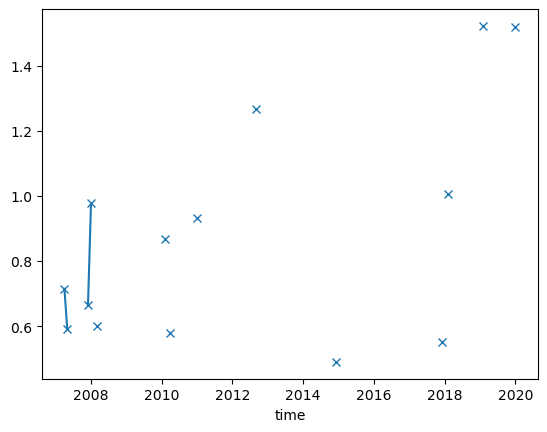

In [29]:
gph.resample({'time':'MS'}).mean().plot(marker='x',linestyle=None)

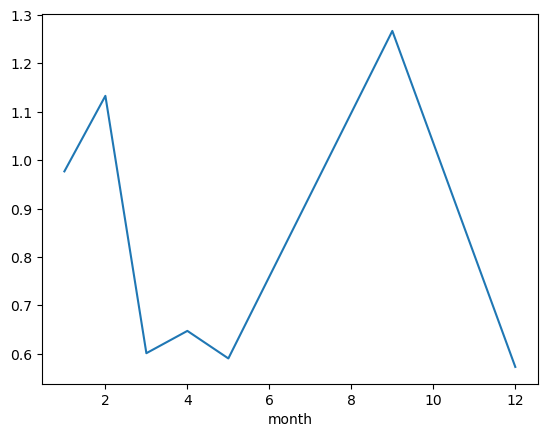

In [30]:
gph.groupby('time.month').mean().plot()

In [31]:
ds_shelf['gph'] = gph

In [32]:
def get_seasons(dspira_mertz):
    seasons={}
    seasons['autumn']=dspira_mertz.where(((dspira_mertz.month >= 4) & (dspira_mertz.month <= 6)),drop=True)
    seasons['winter']=dspira_mertz.where(((dspira_mertz.month >= 7) & (dspira_mertz.month <= 9)),drop=True)
    seasons['spring']=dspira_mertz.where(((dspira_mertz.month >= 10) & (dspira_mertz.month <= 12)),drop=True)
    seasons['summer']=dspira_mertz.where(((dspira_mertz.month >= 1) & (dspira_mertz.month <= 3)),drop=True)
    return seasons
def assign_season(dspira_mertz):
    dspira_mertz['season']=dspira_mertz.where(((dspira_mertz.month >= 4) & (dspira_mertz.month <= 6)),drop=True)
    seasons['winter']=dspira_mertz.where(((dspira_mertz.month >= 7) & (dspira_mertz.month <= 9)),drop=True)
    seasons['spring']=dspira_mertz.where(((dspira_mertz.month >= 10) & (dspira_mertz.month <= 12)),drop=True)
    seasons['summer']=dspira_mertz.where(((dspira_mertz.month >= 1) & (dspira_mertz.month <= 3)),drop=True)
    return seasons
def alt_seasons(dspira_mertz):
    seasons={}
    seasons['autumn']=dspira_mertz.where(((dspira_mertz.month >= 3) & (dspira_mertz.month <= 5)),drop=True)
    seasons['winter']=dspira_mertz.where(((dspira_mertz.month >= 6) & (dspira_mertz.month <= 8)),drop=True)
    seasons['spring']=dspira_mertz.where(((dspira_mertz.month >= 9) & (dspira_mertz.month <= 11)),drop=True)
    seasons['summer']=dspira_mertz.where(((dspira_mertz.month == 12) | (dspira_mertz.month <= 2)),drop=True)
    return seasons
def alt_seasons2(dspira_mertz):
    seasons={}
    seasons['autumn']=dspira_mertz.where(((dspira_mertz.month >= 3) & (dspira_mertz.month <= 5)),drop=True)
    seasons['winter']=dspira_mertz.where(((dspira_mertz.month >= 6) & (dspira_mertz.month <= 8)),drop=True)
    seasons['spring']=dspira_mertz.where(((dspira_mertz.month >= 9) & (dspira_mertz.month <= 11)),drop=True)
    seasons['summer']=dspira_mertz.where(((dspira_mertz.month == 12) | (dspira_mertz.month <= 2)),drop=True)
    return seasons
seasons = get_seasons(ds_shelf)
#seasons = alt_seasons(ds_shelf)

# print(len(seasons['autumn'].time))
# print(len(seasons['winter'].time))
# print(len(seasons['spring'].time))
# print(len(seasons['summer'].time))



In [33]:
rows = ['Summer','Autumn','Winter','Spring']
cols = np.arange(2005,2025,1)
ally = xr.DataArray(cols, coords={'year':cols})

/home/users/eejco/miniforge3/envs/sha-env/lib/python3.14/site-packages/xarray/structure/concat.py:673: UserWarning: No index created for dimension year because variable year is not a coordinate. To create an index for year, please first call `.set_coords('year')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)
/home/users/eejco/miniforge3/envs/sha-env/lib/python3.14/site-packages/xarray/structure/concat.py:673: UserWarning: No index created for dimension year because variable year is not a coordinate. To create an index for year, please first call `.set_coords('year')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)
/home/users/eejco/miniforge3/envs/sha-env/lib/python3.14/site-packages/xarray/structure/concat.py:673: UserWarning: No index created for dimension year because variable year is not a coordinate. To create an index for year, please first call `.set_coords('year')` on this object.
  ds

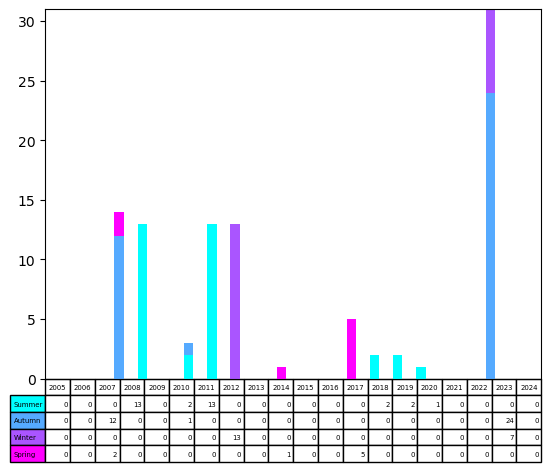

In [34]:
prep4table = lambda season: seasons[season].groupby('time.year').count().month.reindex_like(ally,fill_value=0).values
data = [prep4table('summer'),
        prep4table('autumn'),
        prep4table('winter'),
        prep4table('spring')]

# values = np.arange(0, 2500, 500)
# value_increment = 1000
# Get some pastel shades for the colors
colors = plt.cm.cool(np.linspace(0, 1, len(rows)))
n_rows = len(data)
index = np.arange(len(cols)) + 0.3
bar_width = 0.4
# Initialize the vertical-offset for the stacked bar chart.
y_offset = np.zeros(len(cols))
# Plot bars and create text labels for the table
for row in range(n_rows):
    barc = plt.bar(index, data[row], bar_width, bottom=y_offset, color=colors[row])
    y_offset = y_offset + data[row]

plt.xticks([])
# Add a table at the bottom of the axes
the_table = plt.table(cellText=data,
                      rowLabels=rows,
                      rowColours=colors,
                      colLabels=cols,
                      loc='bottom')





In [35]:
sosessf['month'] = sosessf.time.dt.month
sosetsf['month'] = sosetsf.time.dt.month

thetaseasons = get_seasons(sosetsf)
saltseasons = get_seasons(sosessf)

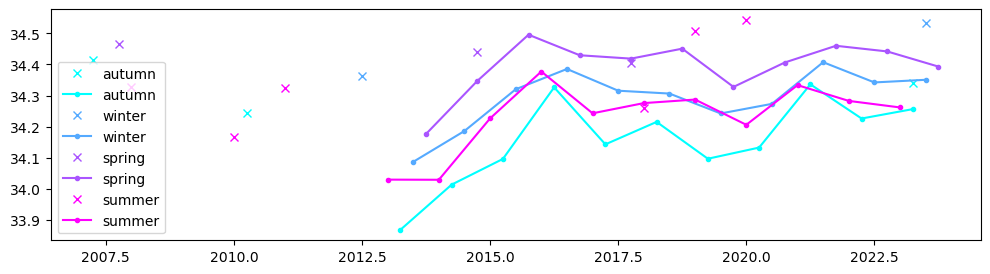

In [36]:
fig,ax= plt.subplots(figsize=(12,3))
offset = {'summer':0,'autumn':0.25,'winter':0.5,'spring':0.75}
for c,s in zip(colors,seasons):
    data = seasons[s].sel(pres=slice(0,300)).mean('pres').psal.groupby('time.year').mean()
    sose = saltseasons[s].sel(Z=slice(0,-300)).mean(['YC','Z']).groupby('time.year').mean()
    ax.plot(data.year+offset[s],data,marker='x',label=s,linestyle='None',c=c)
    ax.plot(sose.year+offset[s],sose,marker='.',label=s,c=c)
ax.legend()

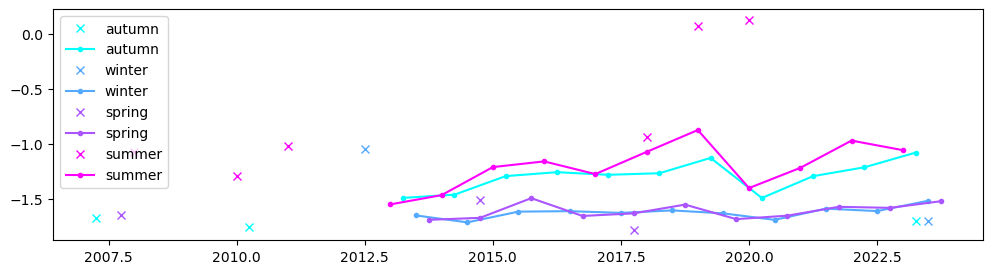

In [37]:
fig,ax= plt.subplots(figsize=(12,3))
offset = {'summer':0,'autumn':0.25,'winter':0.5,'spring':0.75}
for c,s in zip(colors,seasons):
    data = seasons[s].mean('pres').temp.groupby('time.year').mean()
    sose = thetaseasons[s].mean(['YC','Z']).groupby('time.year').mean()
    ax.plot(data.year+offset[s],data,marker='x',label=s,linestyle='None',c=c)
    ax.plot(sose.year+offset[s],sose,marker='.',label=s,c=c)
ax.legend()

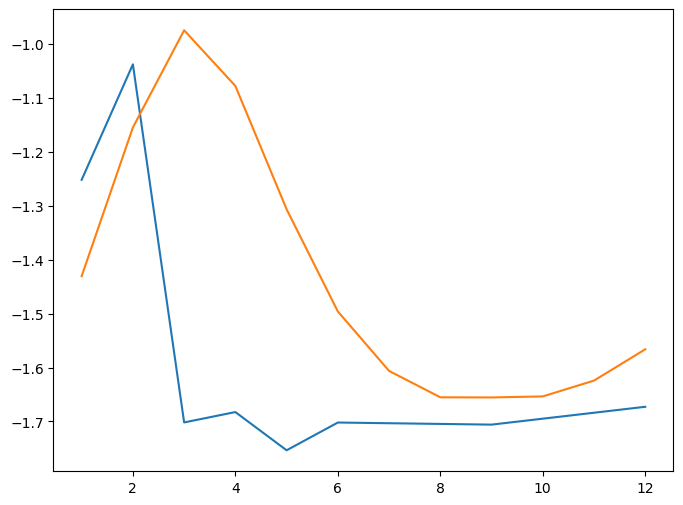

In [38]:
fig,ax = plt.subplots(figsize=(8,6))
data = ds_shelf.temp.sel(pres=slice(0,300)).mean('pres').groupby('time.month').mean()
datas = sosetsf.sel(Z=slice(0,-300)).mean(['Z','YC']).groupby('time.month').mean()
ax.plot(data.month,data,label='seals')
ax.plot(datas.month,datas,label='sose')

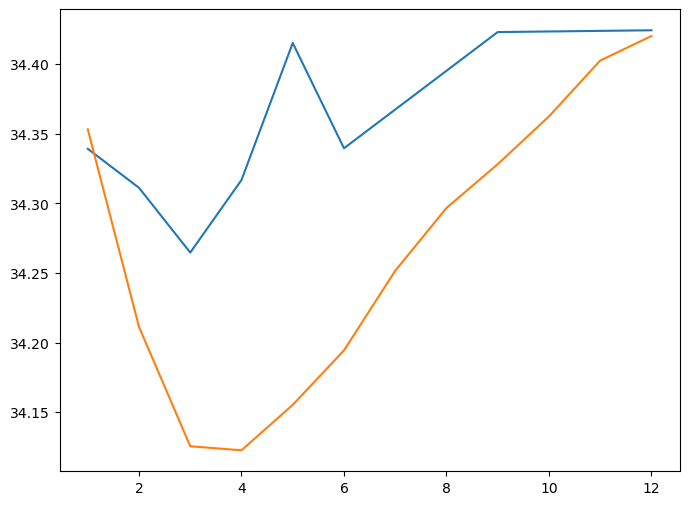

In [39]:
fig,ax = plt.subplots(figsize=(8,6))
data = ds_shelf.psal.sel(pres=slice(0,300)).mean('pres').groupby('time.month').mean()
datas = sosessf.sel(Z=slice(0,-300)).mean(['Z','YC']).groupby('time.month').mean()
ax.plot(data.month,data)
ax.plot(datas.month,datas)

In [41]:
years = ds_shelf.groupby('time.year').mean().year
colors = plt.cm.cubehelix(np.linspace(0, 0.9, len(years)))
colordict = dict(zip(years.to_numpy(),colors))

/home/users/eejco/miniforge3/envs/sha-env/lib/python3.14/site-packages/xarray/structure/concat.py:673: UserWarning: No index created for dimension year because variable year is not a coordinate. To create an index for year, please first call `.set_coords('year')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)


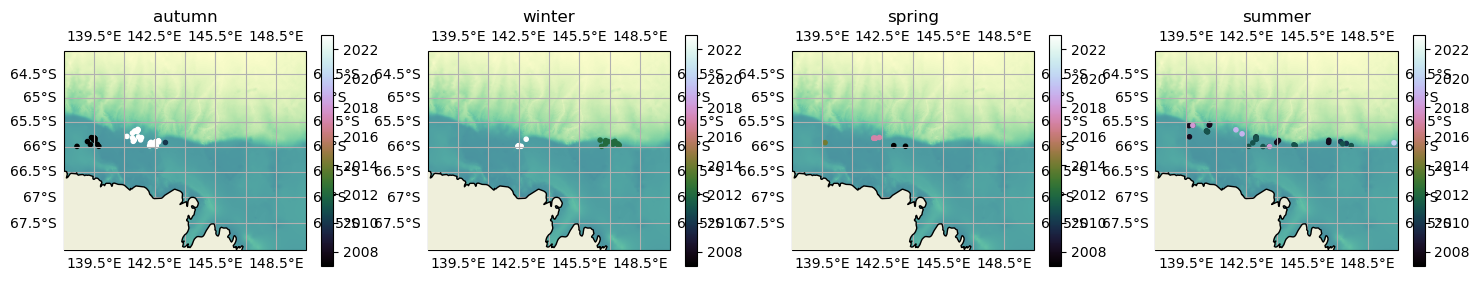

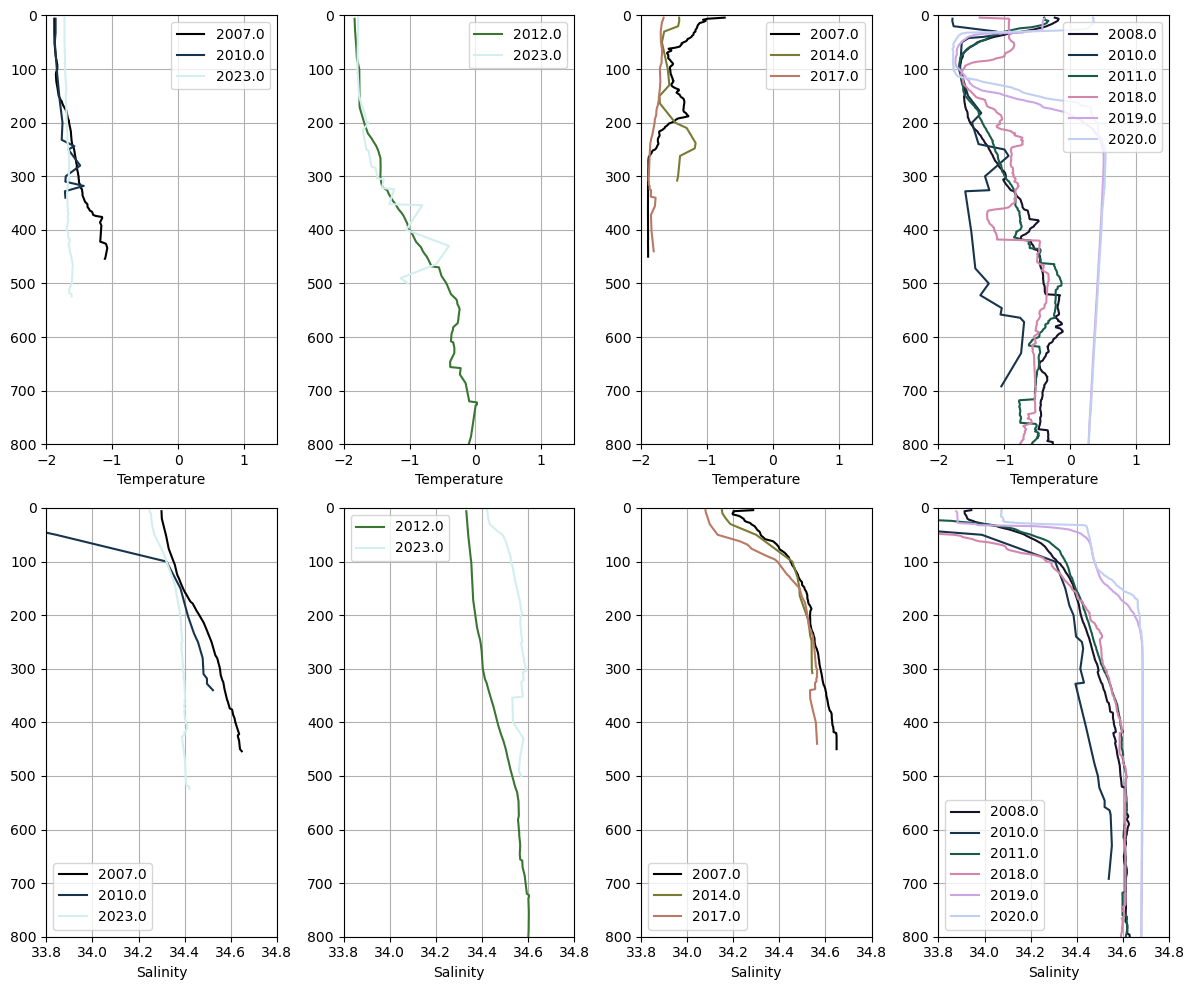

In [42]:

fig,ax=plt.subplots(1,4,figsize=(18,3),subplot_kw={'projection':ccrs.Mercator()})
fig2, ax2 = plt.subplots(2,4,figsize=(12,10))


for i,s in enumerate(seasons):
    dss = seasons[s]
    pfns.sp(ax[i],elevation,extent=extent,cmap=cmocean.cm.deep,land_zorder=3)
    im=ax[i].scatter(dss.lon,dss.lat,c=dss.year,transform=ccrs.PlateCarree(),marker='.',cmap='cubehelix', vmin=int(years.min()), vmax=int(years.max()))
    ax[i].set_title(s)

    plt.colorbar(im)
    plt.tight_layout()

    dsm = dss.mean('time')
    #ax2[i].plot(dsm.ctemp,dsm.pres,c='black')

    for y in np.unique(dss.year):
        dsy = dss.temp.where(dss.year==y,drop=True)
        dsym = dsy.mean('time')
        ax2[0][i].plot(dsym,dsym.pres,c=colordict[y],label=str(y))

        dsy = dss.psal.where(dss.year==y,drop=True)
        dsym = dsy.mean('time')
        ax2[1][i].plot(dsym,dsym.pres,c=colordict[y],label=str(y))

    ax2[0][i].set_xlim([-2,1.5])
    ax2[0][i].set_ylim([0,800])
    ax2[0][i].invert_yaxis()
    ax2[0][i].grid()
    ax2[0][i].set_xlabel('Temperature')
    ax2[0][i].legend()

    ax2[1][i].set_xlim([33.8,34.8])
    ax2[1][i].set_ylim([0,800])
    ax2[1][i].invert_yaxis()
    ax2[1][i].grid()
    ax2[1][i].set_xlabel('Salinity')
    ax2[1][i].legend()


In [43]:
dss

<xarray.Dataset> Size: 867kB
Dimensions:       (time: 33, pres: 501)
Coordinates:
  * time          (time) datetime64[ns] 264B 2008-01-04T22:22:01.996879872 .....
  * pres          (pres) int64 4kB 0 2 4 6 8 10 12 ... 990 992 994 996 998 1000
    lon           (time) float64 264B 143.0 143.0 146.6 ... 142.3 142.0 149.8
    lat           (time) float64 264B -65.84 -65.81 -65.87 ... -65.66 -65.92
    n_prof        (time) float64 264B 5.681e+05 5.681e+05 ... 8.038e+05
Data variables: (12/15)
    temp          (time, pres) float64 132kB nan nan -0.5234 ... 0.1945 0.1937
    psal          (time, pres) float64 132kB nan nan 34.16 ... 34.67 34.67 34.67
    dsource       (time, pres) object 132kB 'CTD' 'CTD' ... 'SOCCOM' 'SOCCOM'
    mld           (time) float64 264B 35.64 21.78 29.7 ... 30.1 29.35 27.62
    asal          (time, pres) float32 66kB nan nan 34.32 ... 34.84 34.84 34.84
    ctemp         (time, pres) float32 66kB nan nan -0.5197 ... 0.1957 0.1949
    ...            ...
    gph           (time) float64 264B 0.6736 1.542 1.415 ... 1.523 1.523 1.521
    elevation     (time) float64 264B -461.9 -977.1 -882.5 ... -876.3 -959.3
    month         (time) float64 264B 1.0 1.0 1.0 1.0 1.0 ... 2.0 2.0 2.0 1.0
    year          (time) float64 264B 2.008e+03 2.008e+03 ... 2.019e+03 2.02e+03
    rho_ref       (time) float64 264B 1.029e+03 1.029e+03 ... 1.029e+03
    vs            (time, pres) float64 132kB nan nan ... 1.499e-07 1.499e-07
Attributes:
    description:  Interpolated dataset from 2004 to 2021. Contains MLD from p...

In [44]:
dss.where(dss.year==2018,drop=True).temp#.sel(pres=500,method='nearest').plot()

<xarray.DataArray 'temp' (time: 2, pres: 501)> Size: 8kB
array([[        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan, -1.37440002, ...,         nan,
                nan,         nan]], shape=(2, 501))
Coordinates:
  * time     (time) datetime64[ns] 16B 2018-02-01T05:15:00 2018-02-02T14:57:5...
  * pres     (pres) int64 4kB 0 2 4 6 8 10 12 ... 988 990 992 994 996 998 1000
    lon      (time) float64 16B 139.9 143.6
    lat      (time) float64 16B -65.57 -66.0
    n_prof   (time) float64 16B 5.66e+05 5.66e+05

In [45]:
y=2024
ds_shelf.sel(time=slice(pd.Timestamp(y,1,1),pd.Timestamp(y+1,1,1))).psal.mean('pres').plot()

TypeError: No numeric data to plot.

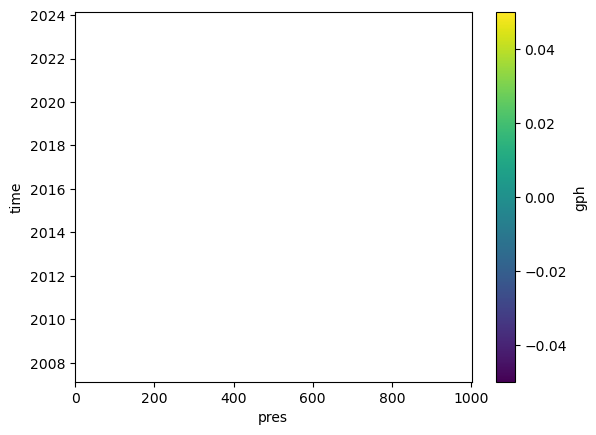

In [ ]:
ds_shelf.gph.plot()

In [ ]:
sic_seasons = get_seasons(sice)
sla_seasons = get_seasons(sla)
ss='spring'
years = [2007,2011,2014,2017]

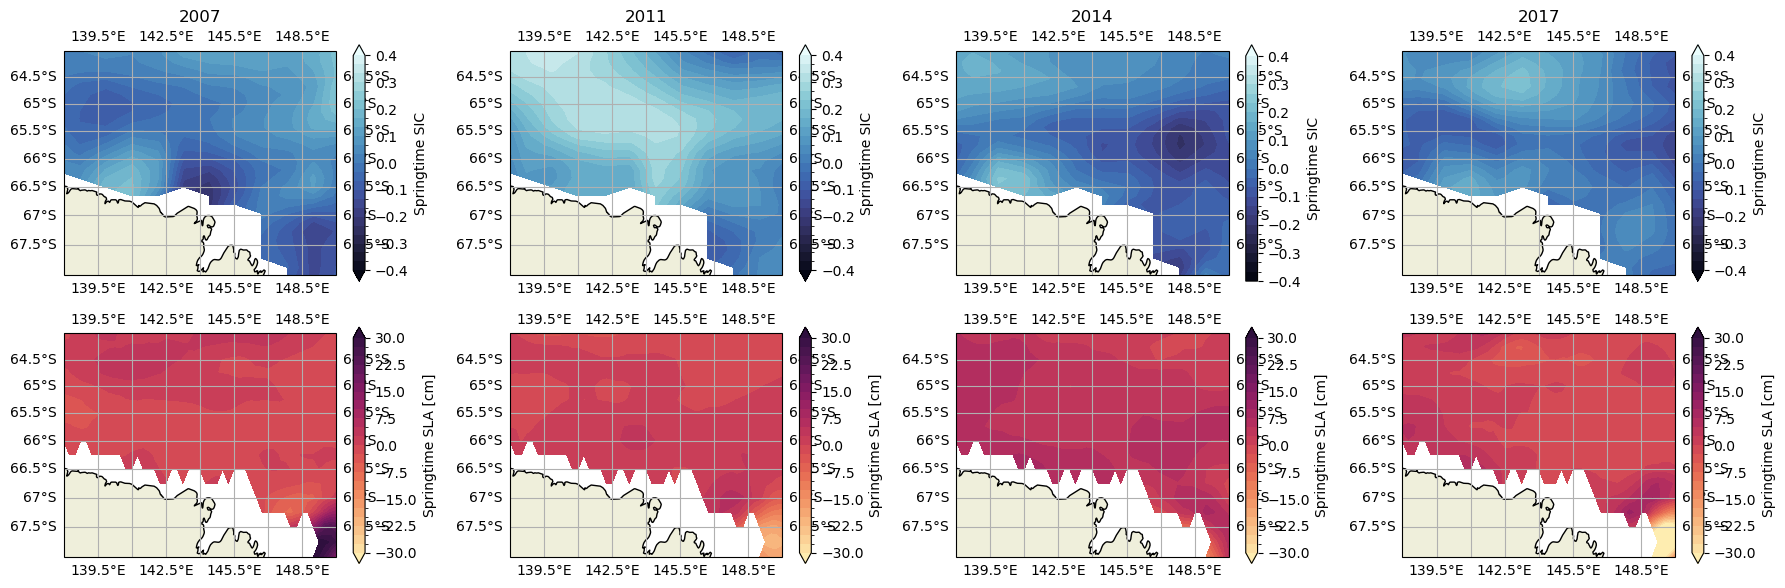

In [ ]:


fig,axs = plt.subplots(2,len(years),figsize=(18,6),subplot_kw={'projection':ccrs.Mercator()})

for i,yr in enumerate(years):
    ax=axs[0]
    sici = sanom(sic_seasons[ss]).where(sic_seasons[ss].time.dt.year == yr,drop=True).mean('time').rename('Springtime SIC')
    sici.plot.contourf(ax=ax[i],transform=ccrs.PlateCarree(),cmap=cmocean.cm.ice,levels=25,vmin=-0.4,vmax=0.4)
    ax[i].set_extent(extent,ccrs.PlateCarree())
    gl = ax[i].gridlines(draw_labels=True)
    ax[i].add_feature(cartopy.feature.LAND, edgecolor='k')
    gl.ylabels_right = False
    ax[i].set_title(str(yr))

    ax=axs[1]
    slai=sanom(sla_seasons[ss]).where(sla_seasons[ss].time.dt.year == yr,drop=True).mean('time').rename('Springtime SLA')
    slai.plot.contourf(ax=ax[i],transform=ccrs.PlateCarree(),cmap=cmocean.cm.matter,levels=25,vmin=-30,vmax=30)
    ax[i].set_extent(extent,ccrs.PlateCarree())
    gl = ax[i].gridlines(draw_labels=True)
    ax[i].add_feature(cartopy.feature.LAND, edgecolor='k')
    gl.ylabels_right = False

plt.tight_layout()

In [ ]:
o200 = seasons[ss].sel(pres=slice(0,500))
temp = o200.temp.to_numpy().flatten()
psal = o200.psal.to_numpy().flatten()
year = np.repeat(o200.year,len(o200.pres))


In [ ]:
tlim=[-2.3,0.1]#[-2.1,-0.5]
slim=[33.7,35] #[33.9,34.8]
colors = plt.cm.tab20b(np.linspace(0, 0.75, len(years)))
temprange,psalrange,sig0range_ = sig0range(tlim,slim)

dse = seasons[ss]

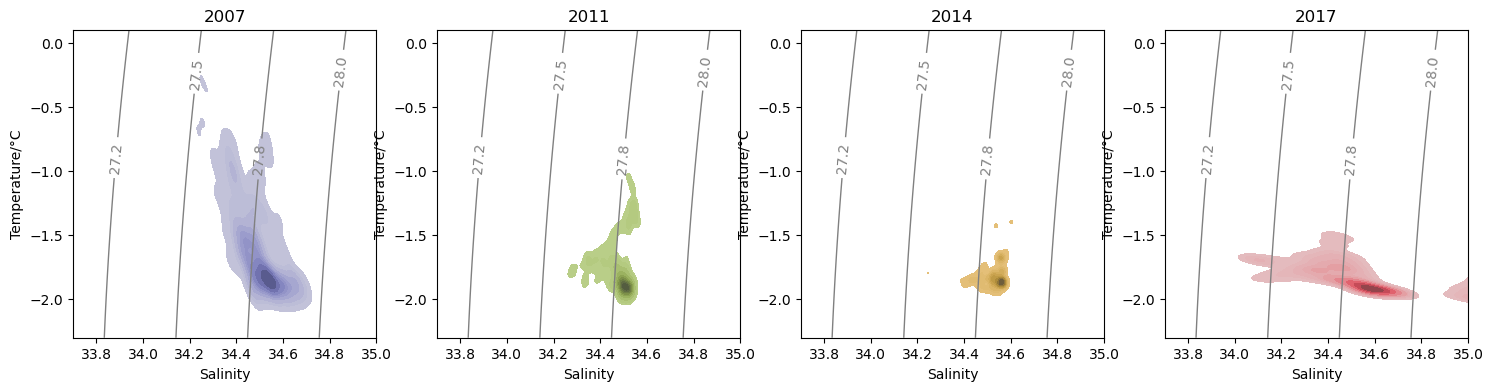

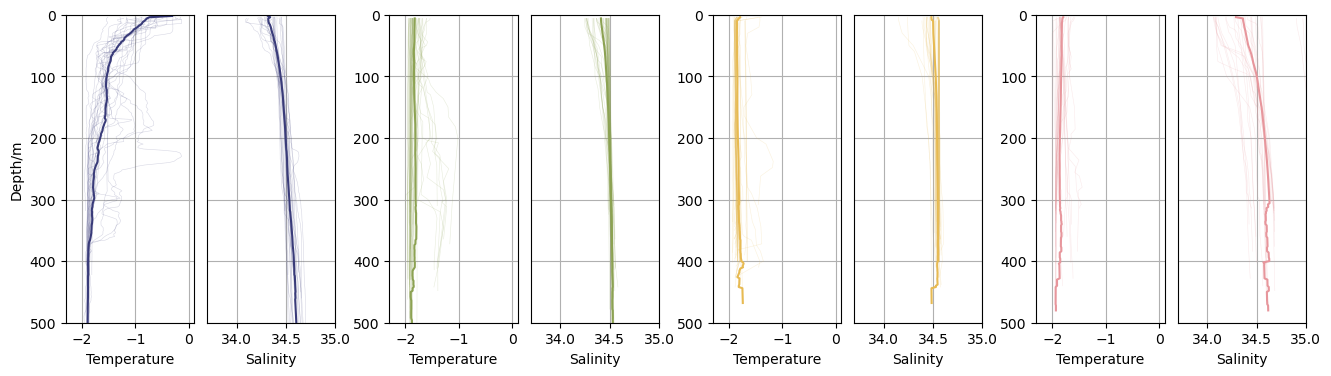

In [ ]:

fig,ax = plt.subplots(1,len(years),figsize=(18,4))


for i,y in enumerate(years):
    psal_ = o200.psal.where(dse.year==y,drop=True).to_numpy().flatten()
    temp_ = o200.temp.where(dse.year==y,drop=True).to_numpy().flatten()
    sns.kdeplot(ax=ax[i],x=psal_,y=temp_,color=colors[i],fill=True)
    cs=ax[i].contour(psalrange,temprange,sig0range_,levels=4,colors='grey',linewidths=1)
    plt.clabel(cs, fontsize=10, inline=1, fmt='%0.1f')
    ax[i].set_xlim(slim)
    ax[i].set_ylim(tlim)
    ax[i].set_xlabel('Salinity')
    ax[i].set_ylabel('Temperature/°C')
    ax[i].set_title(int(y))

    y200 = o200.groupby('year').mean()


fig = plt.figure(figsize=(16,4))
outer = gridspec.GridSpec(1, len(years), wspace=0.2, hspace=0.2)

for i,y in enumerate(years):
    inner = gridspec.GridSpecFromSubplotSpec(1, 2,
                    subplot_spec=outer[i], wspace=0.1, hspace=0.1)

    plt.Subplot(fig, outer[i]).set_title(str(y))

    ax = plt.Subplot(fig, inner[0])
    profs = dse.temp.where(dse.year==y,drop=True)
    for t in profs.time:
        ax.plot(profs.sel(time=t),profs.pres,c=colors[i],alpha=0.2,linewidth=0.4)
    ax.plot(y200.sel(year=y).temp,y200.pres,c=colors[i])

    ax.set_xlim(tlim)
    ax.set_ylim([0,500])
    ax.invert_yaxis()
    ax.grid()
    if i == 0 :
        ax.set_ylabel('Depth/m')
    ax.set_xlabel('Temperature')
    fig.add_subplot(ax)

    ax = plt.Subplot(fig, inner[1])
    profs = dse.psal.where(dse.year==y,drop=True)
    for t in profs.time:
        ax.plot(profs.sel(time=t),profs.pres,c=colors[i],alpha=0.2,linewidth=0.4)
    ax.plot(y200.sel(year=y).psal,y200.pres,c=colors[i])

    ax.set_xlim(slim)
    ax.set_ylim([0,500])
    ax.invert_yaxis()
    ax.grid()
    ax.tick_params(
        axis='y',          
        which='both',      
        left=False,        
        labelleft=False)

    ax.set_xlabel('Salinity')
    fig.add_subplot(ax)


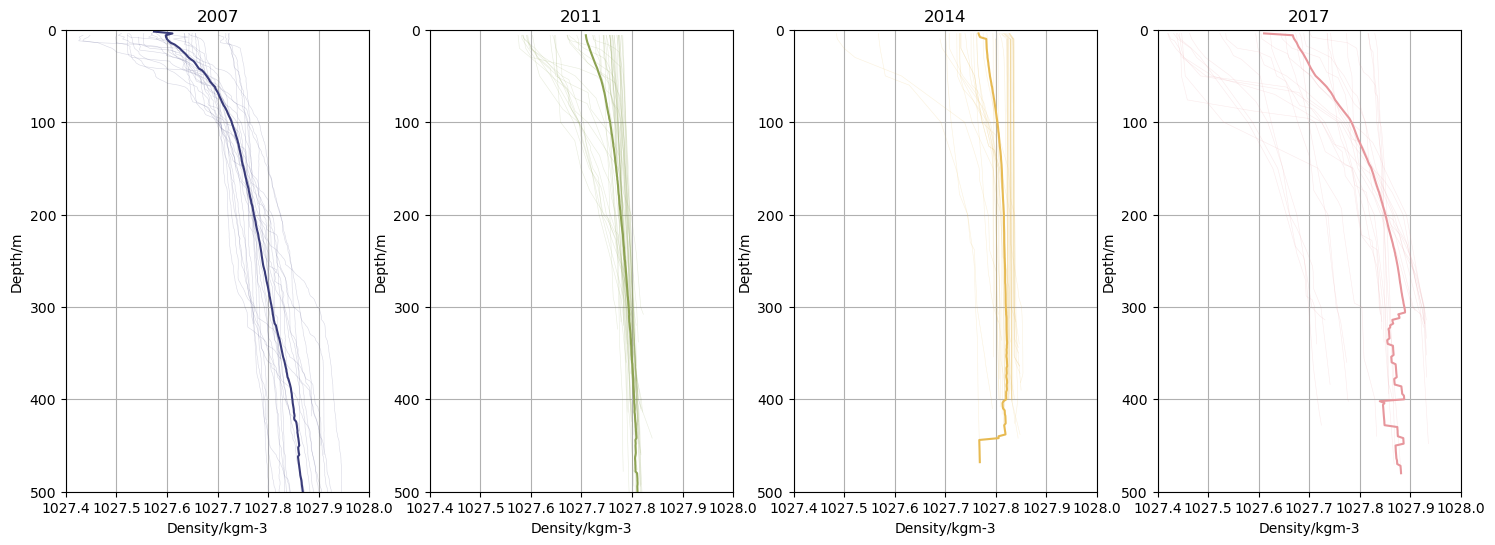

In [ ]:
fig,ax = plt.subplots(1,4,figsize=(18,6))
y200 = o200.groupby('year').mean()
for i,y in enumerate(years):
    profs = dse.rho.where(dse.year==y,drop=True)
    for t in profs.time:
        ax[i].plot(profs.sel(time=t),profs.pres,c=colors[i],alpha=0.2,linewidth=0.4)
    ax[i].plot(y200.sel(year=y).rho,y200.pres,c=colors[i])

    ax[i].set_xlim([1027.4,1028])
    ax[i].set_ylim([0,500])
    ax[i].invert_yaxis()
    ax[i].set_title(y)
    ax[i].grid()
    ax[i].set_ylabel('Depth/m')
    ax[i].set_xlabel('Density/kgm-3')

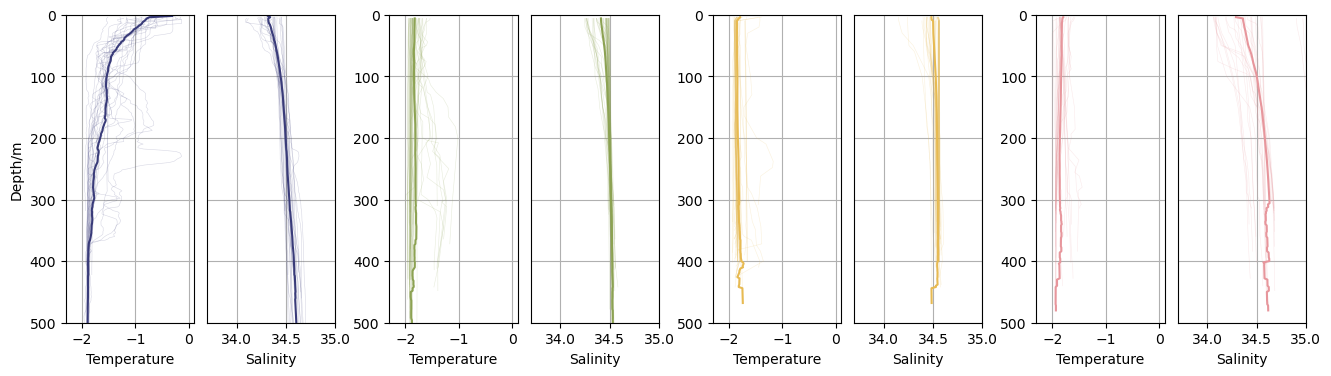

In [ ]:
y200 = o200.groupby('year').mean()


fig = plt.figure(figsize=(16,4))
outer = gridspec.GridSpec(1, 4, wspace=0.2, hspace=0.2)

for i,y in enumerate(years):
    inner = gridspec.GridSpecFromSubplotSpec(1, 2,
                    subplot_spec=outer[i], wspace=0.1, hspace=0.1)

    plt.Subplot(fig, outer[i]).set_title(str(y))

    ax = plt.Subplot(fig, inner[0])
    profs = dse.temp.where(dse.year==y,drop=True)
    for t in profs.time:
        ax.plot(profs.sel(time=t),profs.pres,c=colors[i],alpha=0.2,linewidth=0.4)
    ax.plot(y200.sel(year=y).temp,y200.pres,c=colors[i])

    ax.set_xlim(tlim)
    ax.set_ylim([0,500])
    ax.invert_yaxis()
    ax.grid()
    if i == 0 :
        ax.set_ylabel('Depth/m')
    ax.set_xlabel('Temperature')
    fig.add_subplot(ax)

    ax = plt.Subplot(fig, inner[1])
    profs = dse.psal.where(dse.year==y,drop=True)
    for t in profs.time:
        ax.plot(profs.sel(time=t),profs.pres,c=colors[i],alpha=0.2,linewidth=0.4)
    ax.plot(y200.sel(year=y).psal,y200.pres,c=colors[i])

    ax.set_xlim(slim)
    ax.set_ylim([0,500])
    ax.invert_yaxis()
    ax.grid()
    ax.tick_params(
        axis='y',          
        which='both',      
        left=False,        
        labelleft=False)

    ax.set_xlabel('Salinity')
    fig.add_subplot(ax)


In [ ]:
dse

<xarray.Dataset> Size: 4MB
Dimensions:       (time: 153, pres: 501)
Coordinates:
  * time          (time) datetime64[ns] 1kB 2007-12-22T23:13:31.999511552 ......
  * pres          (pres) int64 4kB 0 2 4 6 8 10 12 ... 990 992 994 996 998 1000
    lon           (time) float64 1kB 142.7 143.1 143.3 ... 138.9 138.6 138.2
    lat           (time) float64 1kB -66.0 -65.98 -66.0 ... -66.86 -66.77 -66.68
    n_prof        (time) float64 1kB 5.681e+05 5.681e+05 ... 7.991e+05 7.991e+05
Data variables: (12/15)
    temp          (time, pres) float64 613kB nan nan -0.6258 ... 0.3305 0.3297
    psal          (time, pres) float64 613kB nan nan 34.22 ... 34.68 34.68 34.68
    dsource       (time, pres) object 613kB 'CTD' 'CTD' ... 'SOCCOM' 'SOCCOM'
    mld           (time) float64 1kB 15.84 19.8 13.86 ... 138.6 130.6 118.8
    asal          (time, pres) float32 307kB nan nan 34.38 ... 34.85 34.85 34.85
    ctemp         (time, pres) float32 307kB nan nan -0.6223 ... 0.3315 0.3307
    ...            ...
    gph           (time) float64 1kB 0.6598 0.6821 0.6983 ... 1.501 1.495 1.495
    elevation     (time) float64 1kB -444.0 -458.2 -465.6 ... -27.18 -219.7
    month         (time) float64 1kB 12.0 12.0 12.0 12.0 ... 10.0 11.0 11.0 11.0
    year          (time) float64 1kB 2.007e+03 2.007e+03 ... 2.018e+03 2.018e+03
    rho_ref       (time) float64 1kB 1.029e+03 1.029e+03 ... 1.029e+03 1.029e+03
    vs            (time, pres) float64 613kB nan nan ... 1.501e-07 1.501e-07
Attributes:
    description:  Interpolated dataset from 2004 to 2021. Contains MLD from p...

In [ ]:
tlim=[-2.1,-0.5]
slim=[33.9,34.8]
colors = plt.cm.tab20b(np.linspace(0, 0.75, n))
temprange,psalrange,sig0range_ = sig0range(tlim,slim)
fig,ax = plt.subplots(figsize=(6,5))
sns.kdeplot(ax=ax,x=psal,y=temp,hue=year, palette=colors)
cs=ax.contour(psalrange,temprange,sig0range_,levels=4,colors='grey',linewidths=1)
plt.clabel(cs, fontsize=10, inline=1, fmt='%0.1f')
ax.set_xlim(slim)
ax.set_ylim(tlim)
ax.set_xlabel('Temperature/°C')
ax.set_ylabel('Salinity')

NameError: name 'n' is not defined

Text(0.5, 0, 'Density/kgm-3')

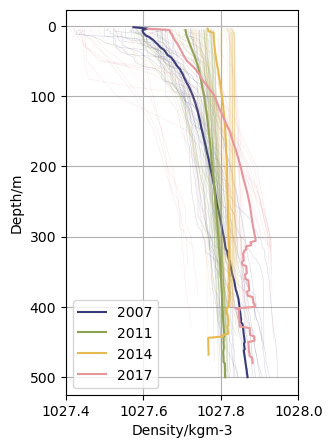

In [ ]:
fig,ax = plt.subplots(figsize=(3,5))
y200 = dse_yr.sel(pres=slice(0,500))
for i,y in enumerate(dse_yr.year):
    profs = o200.rho.where(o200.year==y,drop=True)
    for t in profs.time:
        ax.plot(profs.sel(time=t),profs.pres,c=colors[i],alpha=0.2,linewidth=0.4)
    ax.plot(y200.sel(year=y).rho,profs.pres,c=colors[i],label=str(y.item()))

ax.set_xlim([1027.4,1028])
ax.invert_yaxis()
ax.legend()
ax.grid()
ax.set_ylabel('Depth/m')
ax.set_xlabel('Density/kgm-3')


In [ ]:
data.mean('time'),extent=extent,cmap=cmocean.cm.ice,land_zorder=3)
plt.colorbar(im)

for ax,yr in zip(ax2,dse_yr.year):
    
    for p in data.time:
        data_=data.sel(time=p)
        im=ax.scatter(data_.psal,data_.temp,c=data_.pres,vmin=0,vmax=200)
    ax.set_xlim([34,34.7])
    ax.set_ylim([-2,0])
plt.colorbar(im)

for ax,yr in zip(ax3,dse_yr.year):
    data=dse.where(dse.year == yr,drop=True)
    for p in data.time:
        data_=data.sel(time=p)
        ax.plot(data_.rho,data.pres,c='navajowhite')
    ax.plot(dse_yr.sel(year=yr).rho,dse_yr.pres,c='darkorange')
    ax.set_title(str(yr.item()) + ' ({} profiles)'.format(dse_yr_cnt.sel(year=yr).dsource.item()))
    ax.grid()
    ax.set_xlim([1027.4,1028])
    ax.set_ylim([0,500])
    ax.invert_yaxis()


    

In [ ]:
ds_all.where(ds_all.dsource == 'Argo',drop=True)

<xarray.Dataset> Size: 5MB
Dimensions:       (time: 356, pres: 501)
Coordinates:
  * time          (time) datetime64[ns] 3kB 2006-04-23T04:26:42 ... 2021-12-1...
  * pres          (pres) int64 4kB 0 2 4 6 8 10 12 ... 990 992 994 996 998 1000
    lon           (time) float64 3kB 142.5 143.5 142.9 ... 140.5 140.6 140.6
    lat           (time) float64 3kB -64.01 -64.21 -64.25 ... -64.06 -64.06
    n_prof        (time) float64 3kB 1.199e+05 1.206e+05 ... 2.989e+05 2.989e+05
Data variables:
    temp          (time, pres) float64 1MB nan nan nan ... 1.499 1.496 1.494
    psal          (time, pres) float64 1MB nan nan nan ... 34.74 34.74 34.74
    dsource       (time) object 3kB 'Argo' 'Argo' 'Argo' ... 'Argo' 'Argo'
    mld           (time) float64 3kB 83.76 63.96 78.81 ... 43.47 35.55 47.43
    asal          (time, pres) float32 713kB nan nan nan ... 34.91 34.91 34.91
    ctemp         (time, pres) float32 713kB nan nan nan ... 1.498 1.496 1.494
    rho           (time, pres) float32 713kB nan nan nan ... 1.028e+03 1.028e+03
    mlp           (time) float64 3kB 82.0 60.0 78.0 74.0 ... 36.0 40.0 36.0 46.0
    profile_code  (time) object 3kB nan nan nan nan nan ... nan nan nan nan nan
    elevation     (time) float64 3kB -3.79e+03 -3.639e+03 ... -3.637e+03
    month         (time) float64 3kB 4.0 5.0 5.0 5.0 ... 12.0 12.0 12.0 12.0
    year          (time) float64 3kB 2.006e+03 2.006e+03 ... 2.021e+03 2.021e+03
Attributes:
    description:  Interpolated dataset from 2004 to 2021. Contains MLD from p...

In [ ]:
dse.where(dse.year==2017,drop=True).isel(pres=3)

<xarray.Dataset> Size: 3kB
Dimensions:       (time: 29)
Coordinates:
  * time          (time) datetime64[ns] 232B 2017-11-09T21:30:00.000003 ... 2...
    pres          int64 8B 6
    lon           (time) float64 232B 140.1 141.7 142.2 ... 142.1 142.1 142.1
    lat           (time) float64 232B -66.62 -66.49 -66.51 ... -65.83 -65.83
    n_prof        (time) float64 232B 7.932e+05 7.932e+05 ... 7.932e+05
Data variables:
    temp          (time) float64 232B -1.862 -1.817 -1.811 ... -1.589 -1.614
    psal          (time) float64 232B 34.2 34.27 34.33 ... 34.09 34.07 34.07
    dsource       (time) object 232B 'MEOP' 'MEOP' 'MEOP' ... 'MEOP' 'MEOP'
    mld           (time) float64 232B 23.76 49.5 29.7 43.56 ... 49.5 49.5 49.5
    asal          (time) float32 116B 34.36 34.44 34.5 ... 34.25 34.23 34.23
    ctemp         (time) float32 116B -1.858 -1.813 -1.807 ... -1.586 -1.61
    rho           (time) float32 116B 1.028e+03 1.028e+03 ... 1.027e+03
    mlp           (time) float64 232B 22.0 42.0 22.0 42.0 ... 38.0 30.0 32.0
    profile_code  (time) object 232B nan nan nan nan nan ... nan nan nan nan nan
    elevation     (time) float64 232B -602.0 -399.0 -362.0 ... -427.3 -463.5
    month         (time) float64 232B 11.0 11.0 11.0 11.0 ... 12.0 12.0 12.0
    year          (time) float64 232B 2.017e+03 2.017e+03 ... 2.017e+03
Attributes:
    description:  Interpolated dataset from 2004 to 2021. Contains MLD from p...

In [ ]:
dsw.where(dsw.year==2017,drop=True).isel(pres=3).rho

<xarray.DataArray 'rho' (time: 9)> Size: 36B
array([1027.5352, 1027.6051, 1027.5251, 1027.4342, 1027.4409, 1027.4647,
       1028.164 , 1028.1091, 1028.1913], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 72B 2017-11-09T21:30:00.000003 ... 2017-12...
    pres     int64 8B 6
    lon      (time) float64 72B 140.1 140.1 140.2 140.2 ... 140.2 140.2 141.0
    lat      (time) float64 72B -66.62 -66.63 -66.6 ... -66.55 -66.62 -66.77
    n_prof   (time) float64 72B 7.932e+05 7.932e+05 ... 5.99e+05 5.99e+05
Attributes:
    long_name:      In-situ Density
    standard_name:  rho
    units:          kg/m^-3

In [ ]:
ds_shelf.rho.where(ds_shelf.rho > 1028,drop=True)

<xarray.DataArray 'rho' (time: 9, pres: 322)> Size: 12kB
array([[      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       ...,
       [1028.164 , 1028.1647, 1028.1654, ...,       nan,       nan,
              nan],
       [1028.1091, 1028.1112, 1028.1133, ...,       nan,       nan,
              nan],
       [1028.1913, 1028.1936, 1028.1959, ...,       nan,       nan,
              nan]], dtype=float32)
Coordinates:
    lon      (time) float64 72B 141.2 141.1 141.1 141.1 ... 140.2 140.2 141.0
    lat      (time) float64 72B -66.54 -66.78 -66.59 ... -66.55 -66.62 -66.77
  * time     (time) datetime64[ns] 72B 2007-06-28T02:39:58.999996 ... 2017-12...
    n_prof   (time) int64 72B 793301 673587 673562 ... 598956 598957 598958
  * pres     (pres) int64 3kB 6 8 10 12 14 16 18 ... 754 756 758 760 762 764 766
Attributes:
    long_name:      In-situ Density
    standard_name:  rho
    units:          kg/m^-3

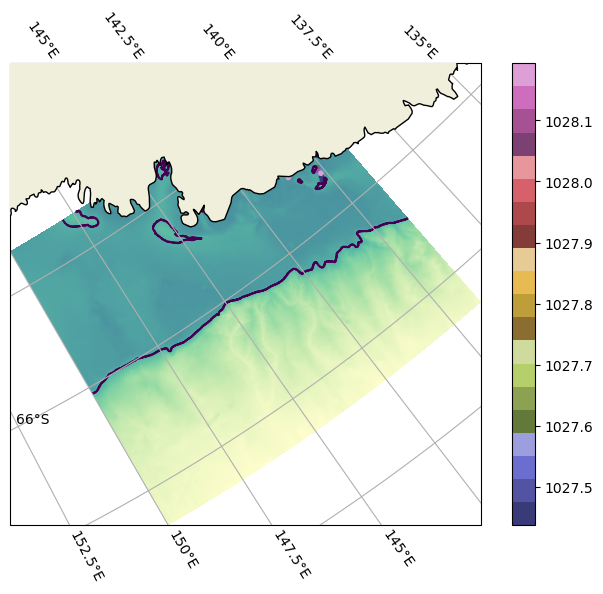

In [ ]:
data = dsw.where(dsw.year==2017,drop=True)
fig,ax=plt.subplots(figsize=(8,6),subplot_kw={'projection':ccrs.SouthPolarStereo()})
pfns.sp(ax,elevation,extent=extent,cmap=cmocean.cm.deep,land_zorder=3)

im=ax.scatter(data.lon,data.lat,c=data.rho.isel(pres=4),transform=ccrs.PlateCarree(),marker='.',cmap='tab20b')
ax.contour(elevation.longitude,elevation.latitude, elevation,levels=[-1000],transform=ccrs.PlateCarree())
plt.colorbar(im)

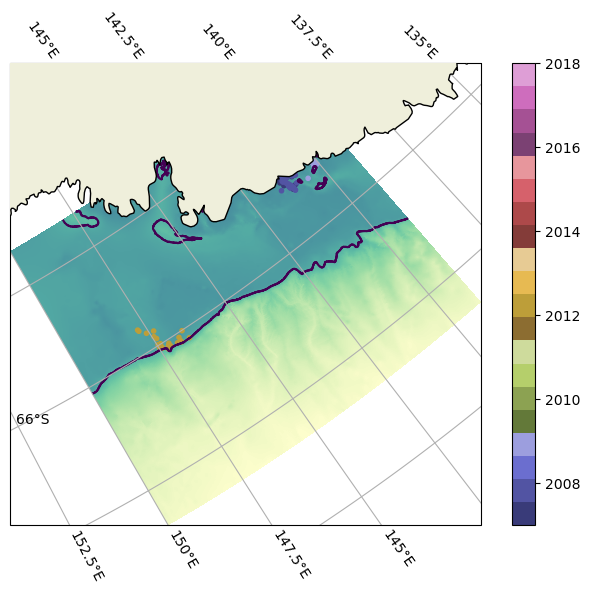

In [ ]:
ssn=seasons['winter']
ssn['year'] = ssn.time.dt.year

fig,ax=plt.subplots(figsize=(8,6),subplot_kw={'projection':ccrs.SouthPolarStereo()})
pfns.sp(ax,elevation,extent=extent,cmap=cmocean.cm.deep,land_zorder=3)

im=ax.scatter(ssn.lon,ssn.lat,c=ssn.year,transform=ccrs.PlateCarree(),marker='.',cmap='tab20b')
ax.contour(elevation.longitude,elevation.latitude, elevation,levels=[-1000],transform=ccrs.PlateCarree())
plt.colorbar(im)

In [ ]:
data_.to_dataframe()

,temp,psal,dsource,mld,asal,ctemp,rho,mlp,elevation,month,year,lon,lat,time,n_prof
pres,,,,,,,,,,,,,,,
0,NaN,NaN,SOCCOM,118.771225,NaN,NaN,NaN,120.0,-72.696,9.0,2018,140.367,-67.22,2018-09-28 15:25:00.000001024,799118
2,NaN,NaN,SOCCOM,118.771225,NaN,NaN,NaN,120.0,-72.696,9.0,2018,140.367,-67.22,2018-09-28 15:25:00.000001024,799118
4,NaN,NaN,SOCCOM,118.771225,NaN,NaN,NaN,120.0,-72.696,9.0,2018,140.367,-67.22,2018-09-28 15:25:00.000001024,799118
6,NaN,NaN,SOCCOM,118.771225,NaN,NaN,NaN,120.0,-72.696,9.0,2018,140.367,-67.22,2018-09-28 15:25:00.000001024,799118
8,NaN,NaN,SOCCOM,118.771225,NaN,NaN,NaN,120.0,-72.696,9.0,2018,140.367,-67.22,2018-09-28 15:25:00.000001024,799118
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
992,0.335580,34.682620,SOCCOM,118.771225,34.849487,0.336616,1027.839722,120.0,-72.696,9.0,2018,140.367,-67.22,2018-09-28 15:25:00.000001024,799118
994,0.335046,34.682561,SOCCOM,118.771225,34.849426,0.336083,1027.839722,120.0,-72.696,9.0,2018,140.367,-67.22,2018-09-28 15:25:00.000001024,799118
996,0.334511,34.682501,SOCCOM,118.771225,34.849369,0.335549,1027.839722,120.0,-72.696,9.0,2018,140.367,-67.22,2018-09-28 15:25:00.000001024,799118


ValueError: cannot handle a non-unique multi-index!

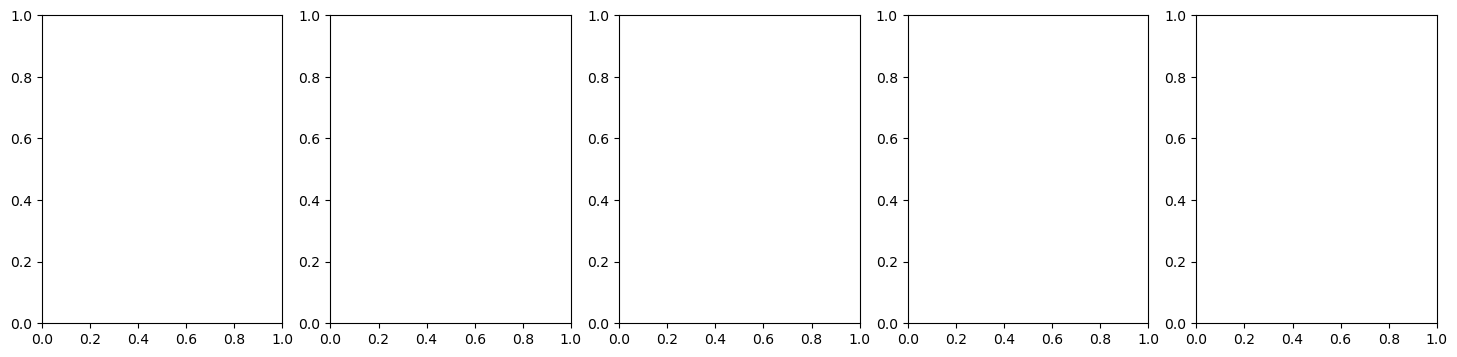

In [ ]:
ds_yr = ssn.groupby('time.year').mean()
ds_yr_cnt = ssn.groupby('time.year').count()

fig,ax = plt.subplots(1,len(ds_yr.year),figsize=(18,4))
for i,yr in enumerate(ds_yr.year):
    data_=ssn.where(ssn.year == yr,drop=True)
    sns.kdeplot(ax=ax[i],data=data_.to_dataframe(),x='psal',y='temp')

fig,ax = plt.subplots(1,len(ds_yr.year),figsize=(18,6))

for i,yr in enumerate(ds_yr.year):
    data=ssn.where(ssn.year == yr,drop=True)
    for p in data.time:
        data_=data.sel(time=p)
        try:
            ax[i].plot(data_.rho,data.pres,c='navajowhite')
        except:
            for l in data_.lat:
                ax[i].plot(data_.rho.swap_dims({'time':'lat'}).sel(lat=l),data.pres,c='navajowhite')
    ax[i].plot(ds_yr.sel(year=yr).rho,ds_yr.pres,c='darkorange')
    ax[i].set_title(str(yr.item()) + ' ({} profiles)'.format(ds_yr_cnt.sel(year=yr).dsource.item()))
    ax[i].invert_yaxis()
    ax[i].grid()
    ax[i].set_xlim([1027.4,1028.4])
    ax[i].set_ylim([0,600])

preparing lag=0 months
preparing data
plotting..
preparing lag=1 months
preparing data
plotting..
preparing lag=2 months
preparing data
plotting..
preparing lag=3 months
preparing data
plotting..
preparing lag=4 months
preparing data
plotting..
preparing lag=5 months
preparing data
plotting..
preparing lag=6 months
preparing data
plotting..


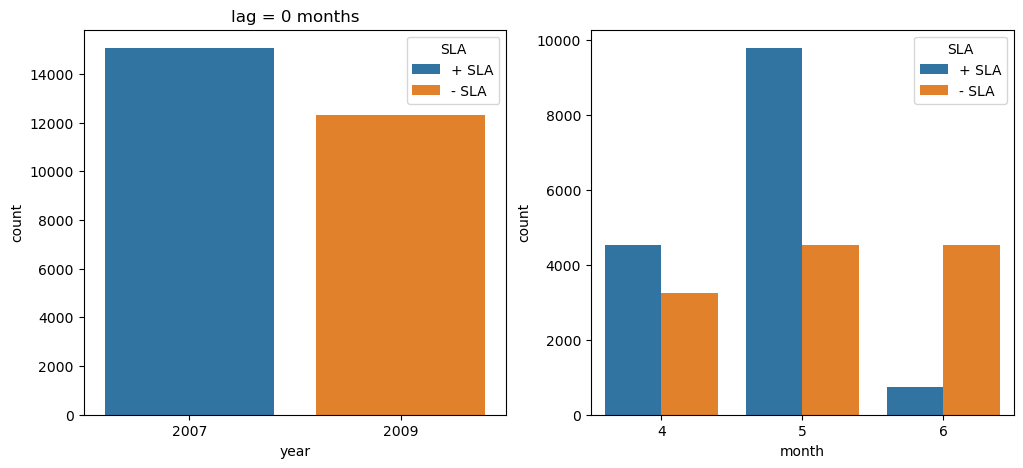

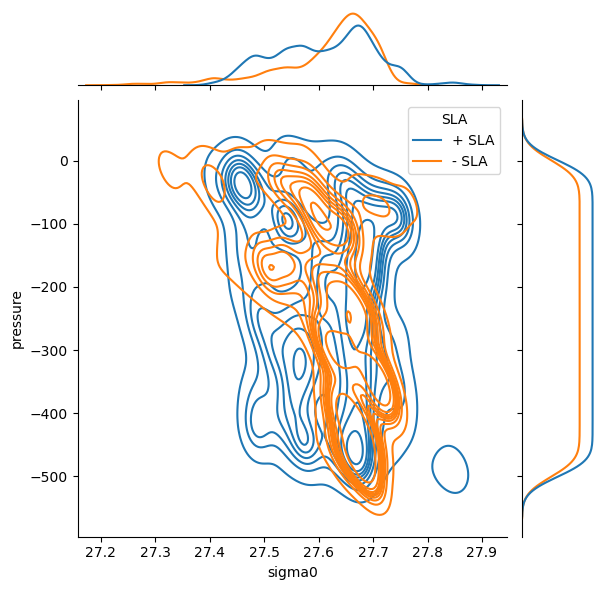

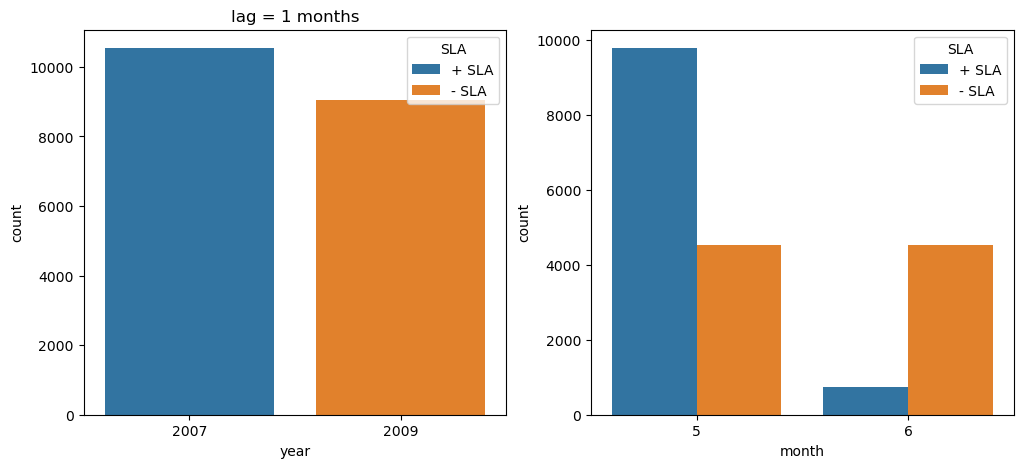

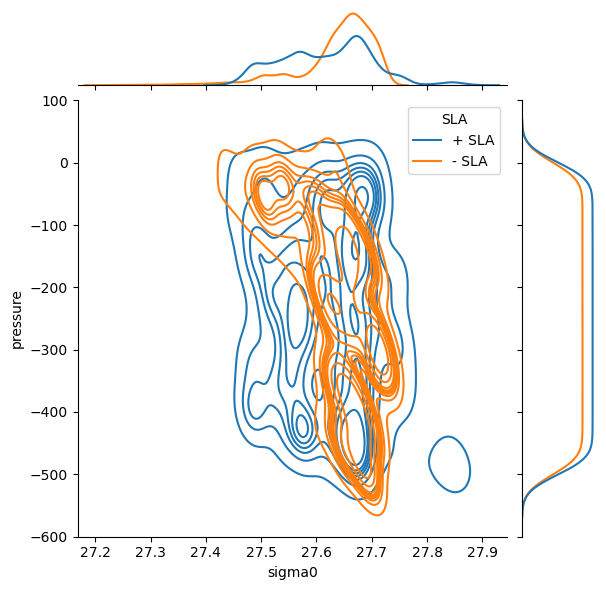

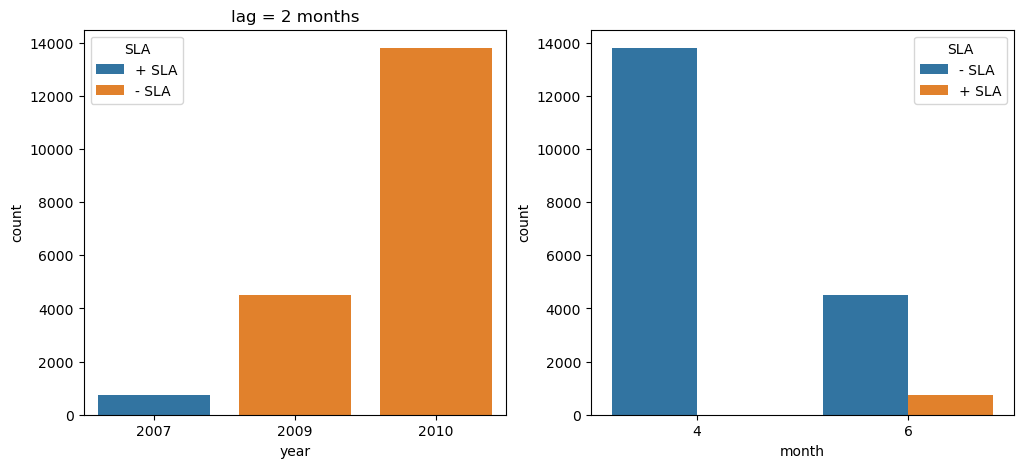

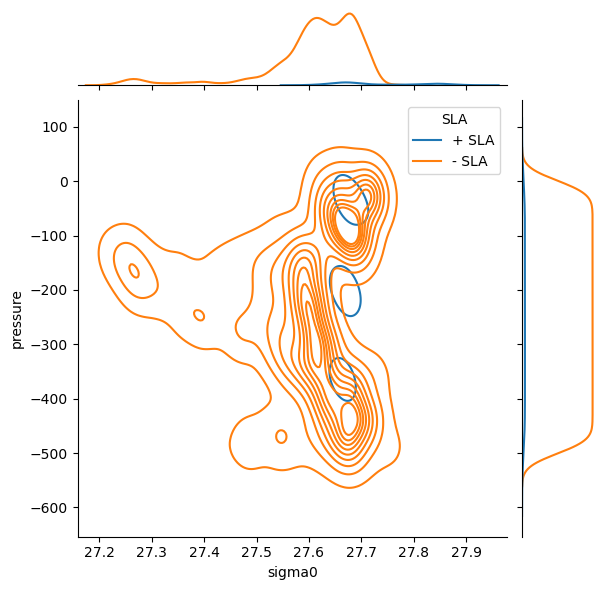

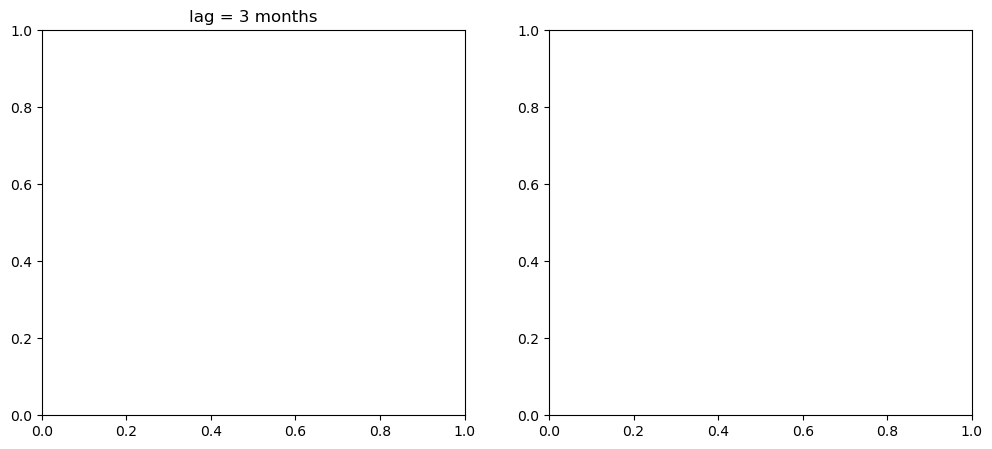

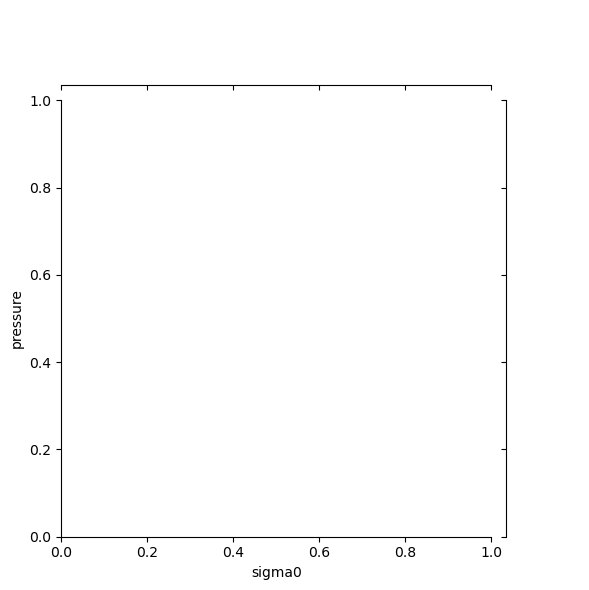

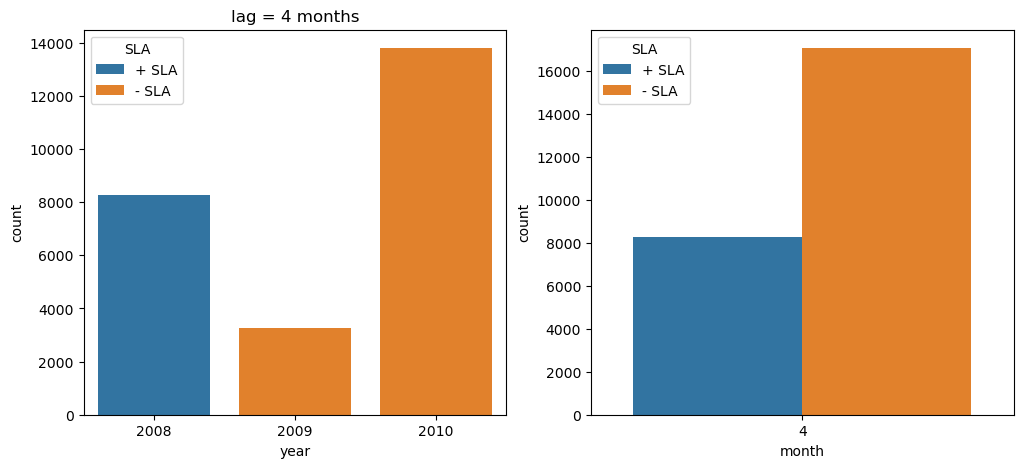

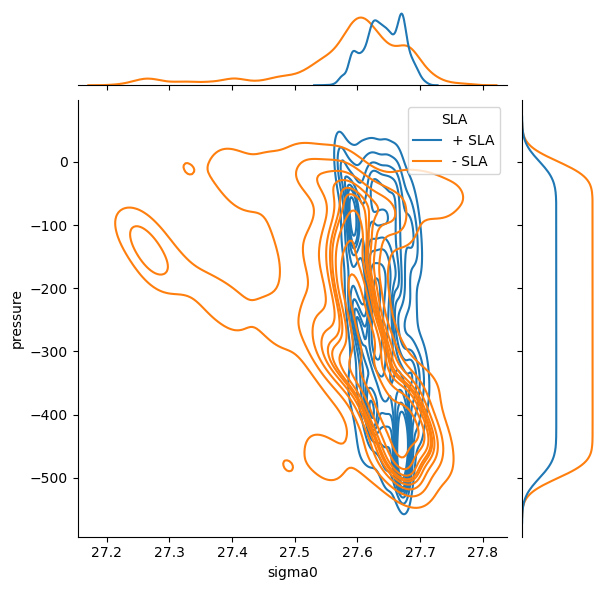

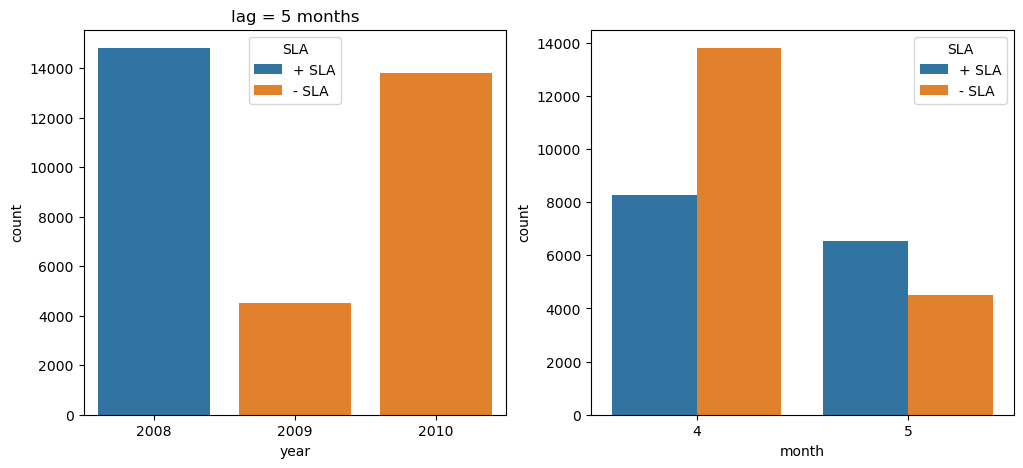

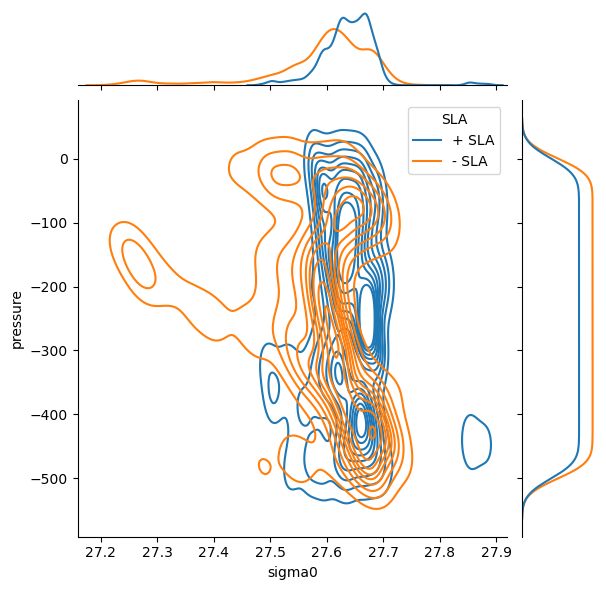

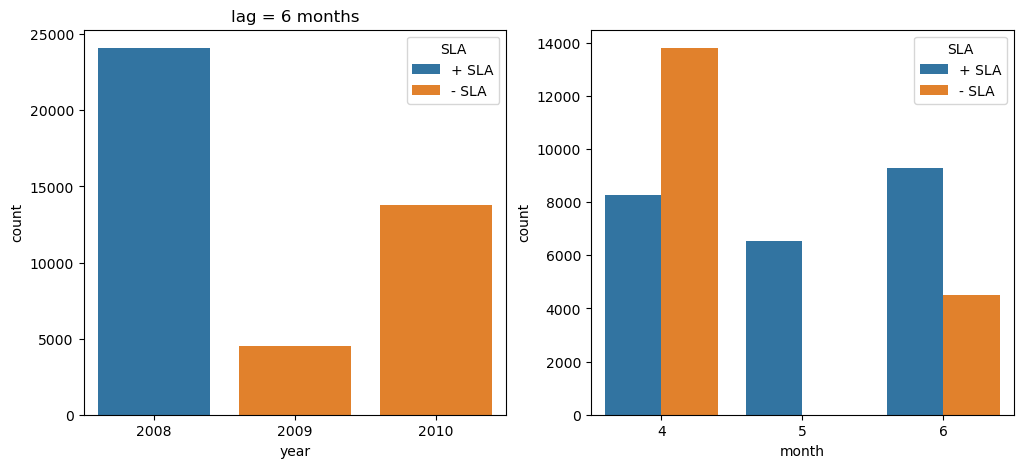

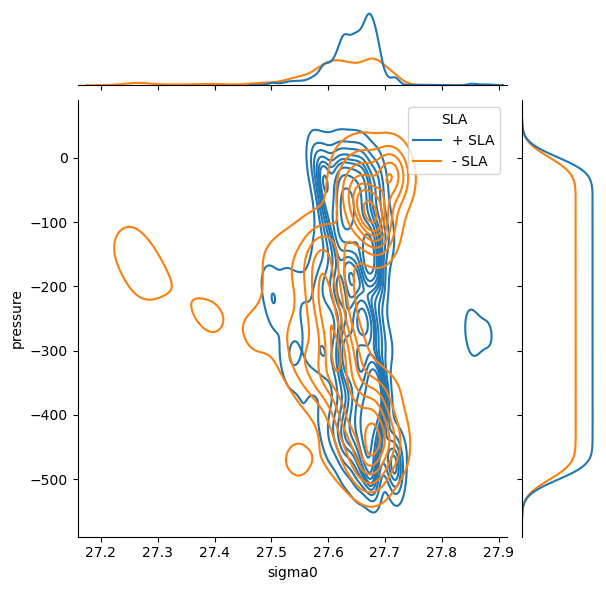

In [ ]:
background_data = sanom(mertz.crop_da(sla)).mean(['latitude','longitude'])
background_data = utls.detrend_dim(background_data,'time')
idx_data = background_data.rolling(time=12,center=True).mean('time')

for l in np.arange(7):
    print('preparing lag={} months'.format(l))
    cmp = Composite(idx_data,'SLA')
    cmp.add_spira(seasons['autumn'],tlims=tlims,slims=slims,lag=l)
    cmp.build_sns_data()

    fig, ax = plt.subplots(1,2,figsize=(12,5))
    sns.countplot(cmp.sns_data, x='year', hue='SLA',ax=ax[0])
    sns.countplot(cmp.sns_data, x='month', hue='SLA',ax=ax[1])
    ax[0].set_title('lag = {} months'.format(l))

    print('plotting..')
    g = sns.JointGrid(data=cmp.sns_data, x='sigma0', y ='pressure', hue='SLA')
    g.plot(sns.kdeplot, sns.kdeplot)

In [ ]:
cmp = Composite(idx_data,'SLA')
cmp.add_spira(seasons['autumn'],tlims=tlims,slims=slims,lag=4)
cmp.build_sns_data()

preparing data


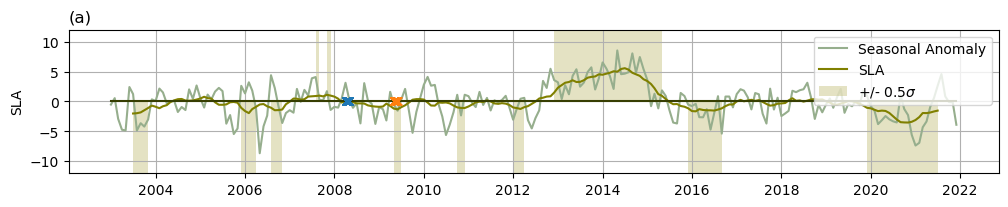

In [33]:
fig = plt.figure(figsize=(12,22))
gs = fig.add_gridspec(10,4)

# FIG1: SLA/SAM TIMESERIES
ax1 = fig.add_subplot(gs[0, :])

cmp.composite_timeseries(ax1,background_data,bg_name='Seasonal Anomaly')

ValueError: x and y must have same first dimension, but have shapes (2, 251) and (251,)

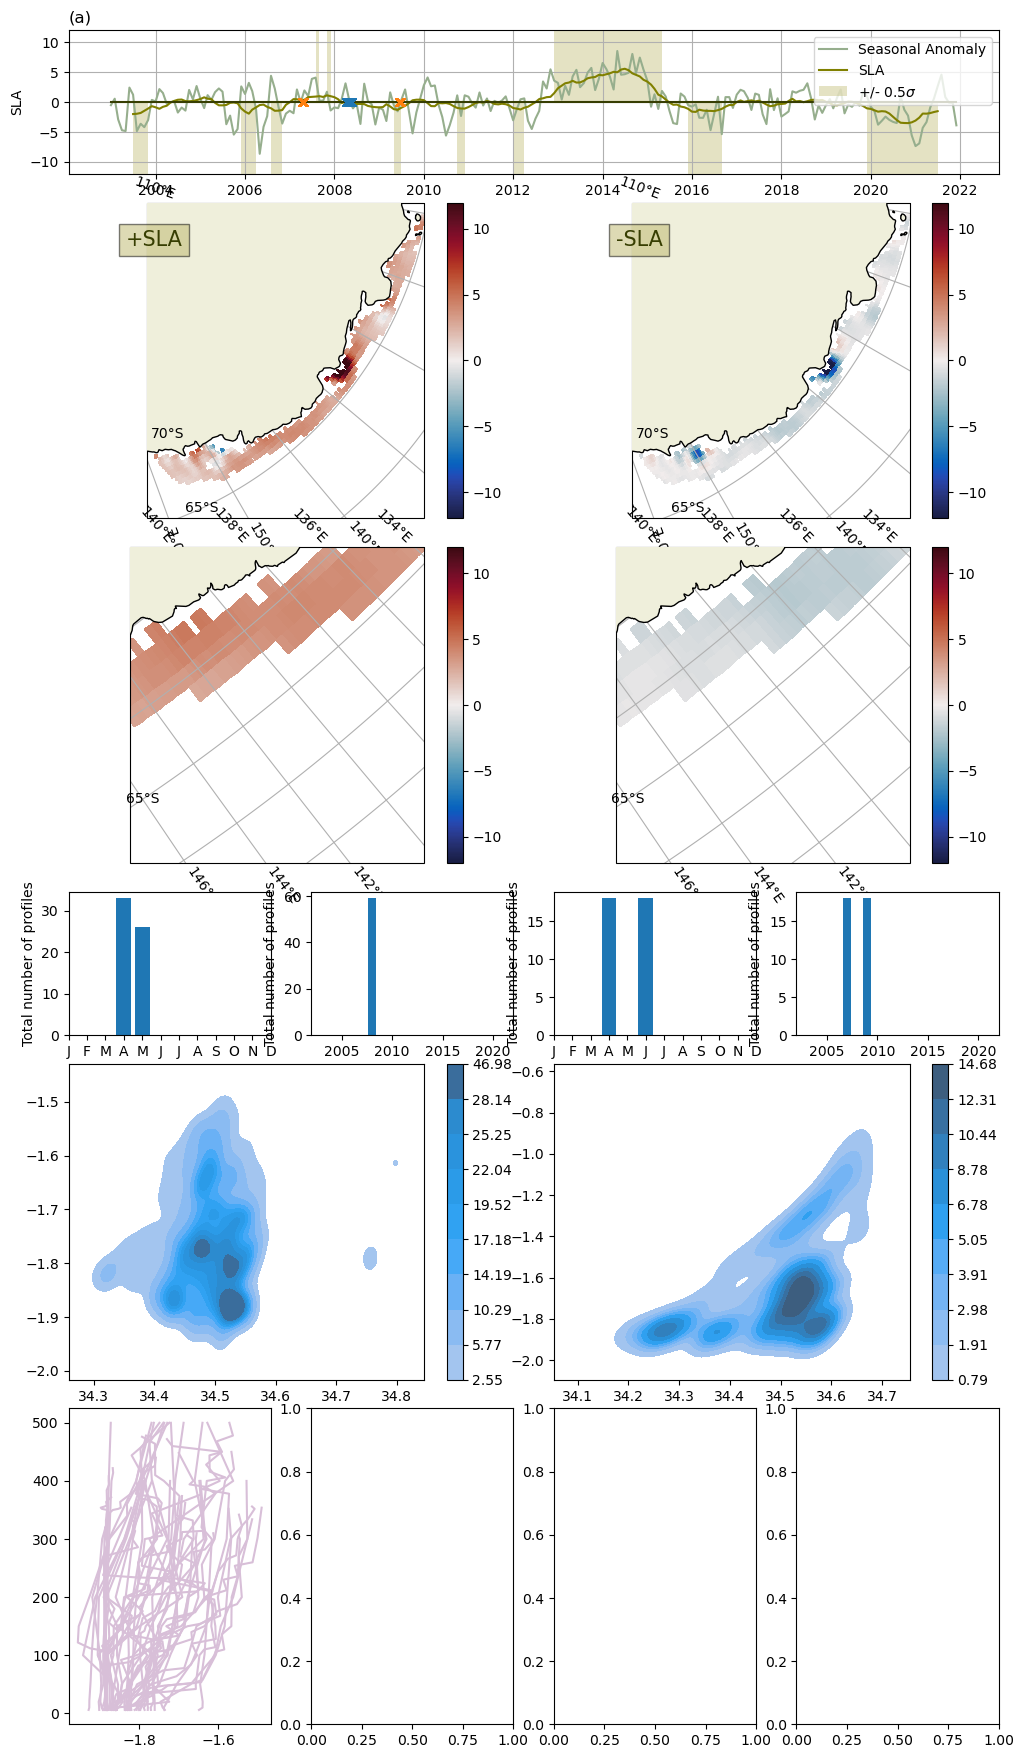

In [29]:
fig = plt.figure(figsize=(12,22))
gs = fig.add_gridspec(10,4)

# FIG1: SLA/SAM TIMESERIES
ax1 = fig.add_subplot(gs[0, :])

cmp.composite_timeseries(ax1,background_data,bg_name='Seasonal Anomaly')
# FIG2: SLA MAP
ax2 = fig.add_subplot(gs[1:3, 0:2],projection=ccrs.SouthPolarStereo())
ax3 = fig.add_subplot(gs[1:3, 2:4],projection=ccrs.SouthPolarStereo())
cmp.posneg_map([ax2,ax3],sanom(shelf.crop_da(sla)),'SLA',12,extent,label_loc=[130,-80])

# FIG3: SLA closeup
ax4 = fig.add_subplot(gs[3:5, 0:2],projection=ccrs.SouthPolarStereo())
ax5 = fig.add_subplot(gs[3:5, 2:4],projection=ccrs.SouthPolarStereo())
cmp.posneg_map([ax4,ax5],sanom(shelf.crop_da(sla)),'SLA',12,extent_mertz,add_profiles=True)

n = 5
cmp.ts_freq_plot([ 
    fig.add_subplot(gs[n,0]),
    fig.add_subplot(gs[n,1]),
    fig.add_subplot(gs[n,2]),
    fig.add_subplot(gs[n,3]),
])

# FIG4: TS DESNITY
n = 6
# cmp.ts_density([
    # fig.add_subplot(gs[n:n+2,0:2]),
    # fig.add_subplot(gs[n:n+2,2:4])
    # ])

ax6 = fig.add_subplot(gs[n:n+2,0:2])
ax7 = fig.add_subplot(gs[n:n+2,2:4])

sns.kdeplot(ax=ax6,x=cmp.s_pos.values.flatten(), y=cmp.t_pos.values.flatten(), fill=True, cbar=True)
sns.kdeplot(ax=ax7, x=cmp.s_neg.values.flatten(), y=cmp.t_neg.values.flatten(),fill=True, cbar=True)

# FIG5: TS PROFILES
n = 8
ax8 = fig.add_subplot(gs[8:10,0])
ax9 = fig.add_subplot(gs[8:10,1])
ax10 = fig.add_subplot(gs[8:10,2])
ax11 = fig.add_subplot(gs[8:10,3])
cmp.ts_profiles([ax8,ax9,ax10,ax11])

plt.tight_layout()



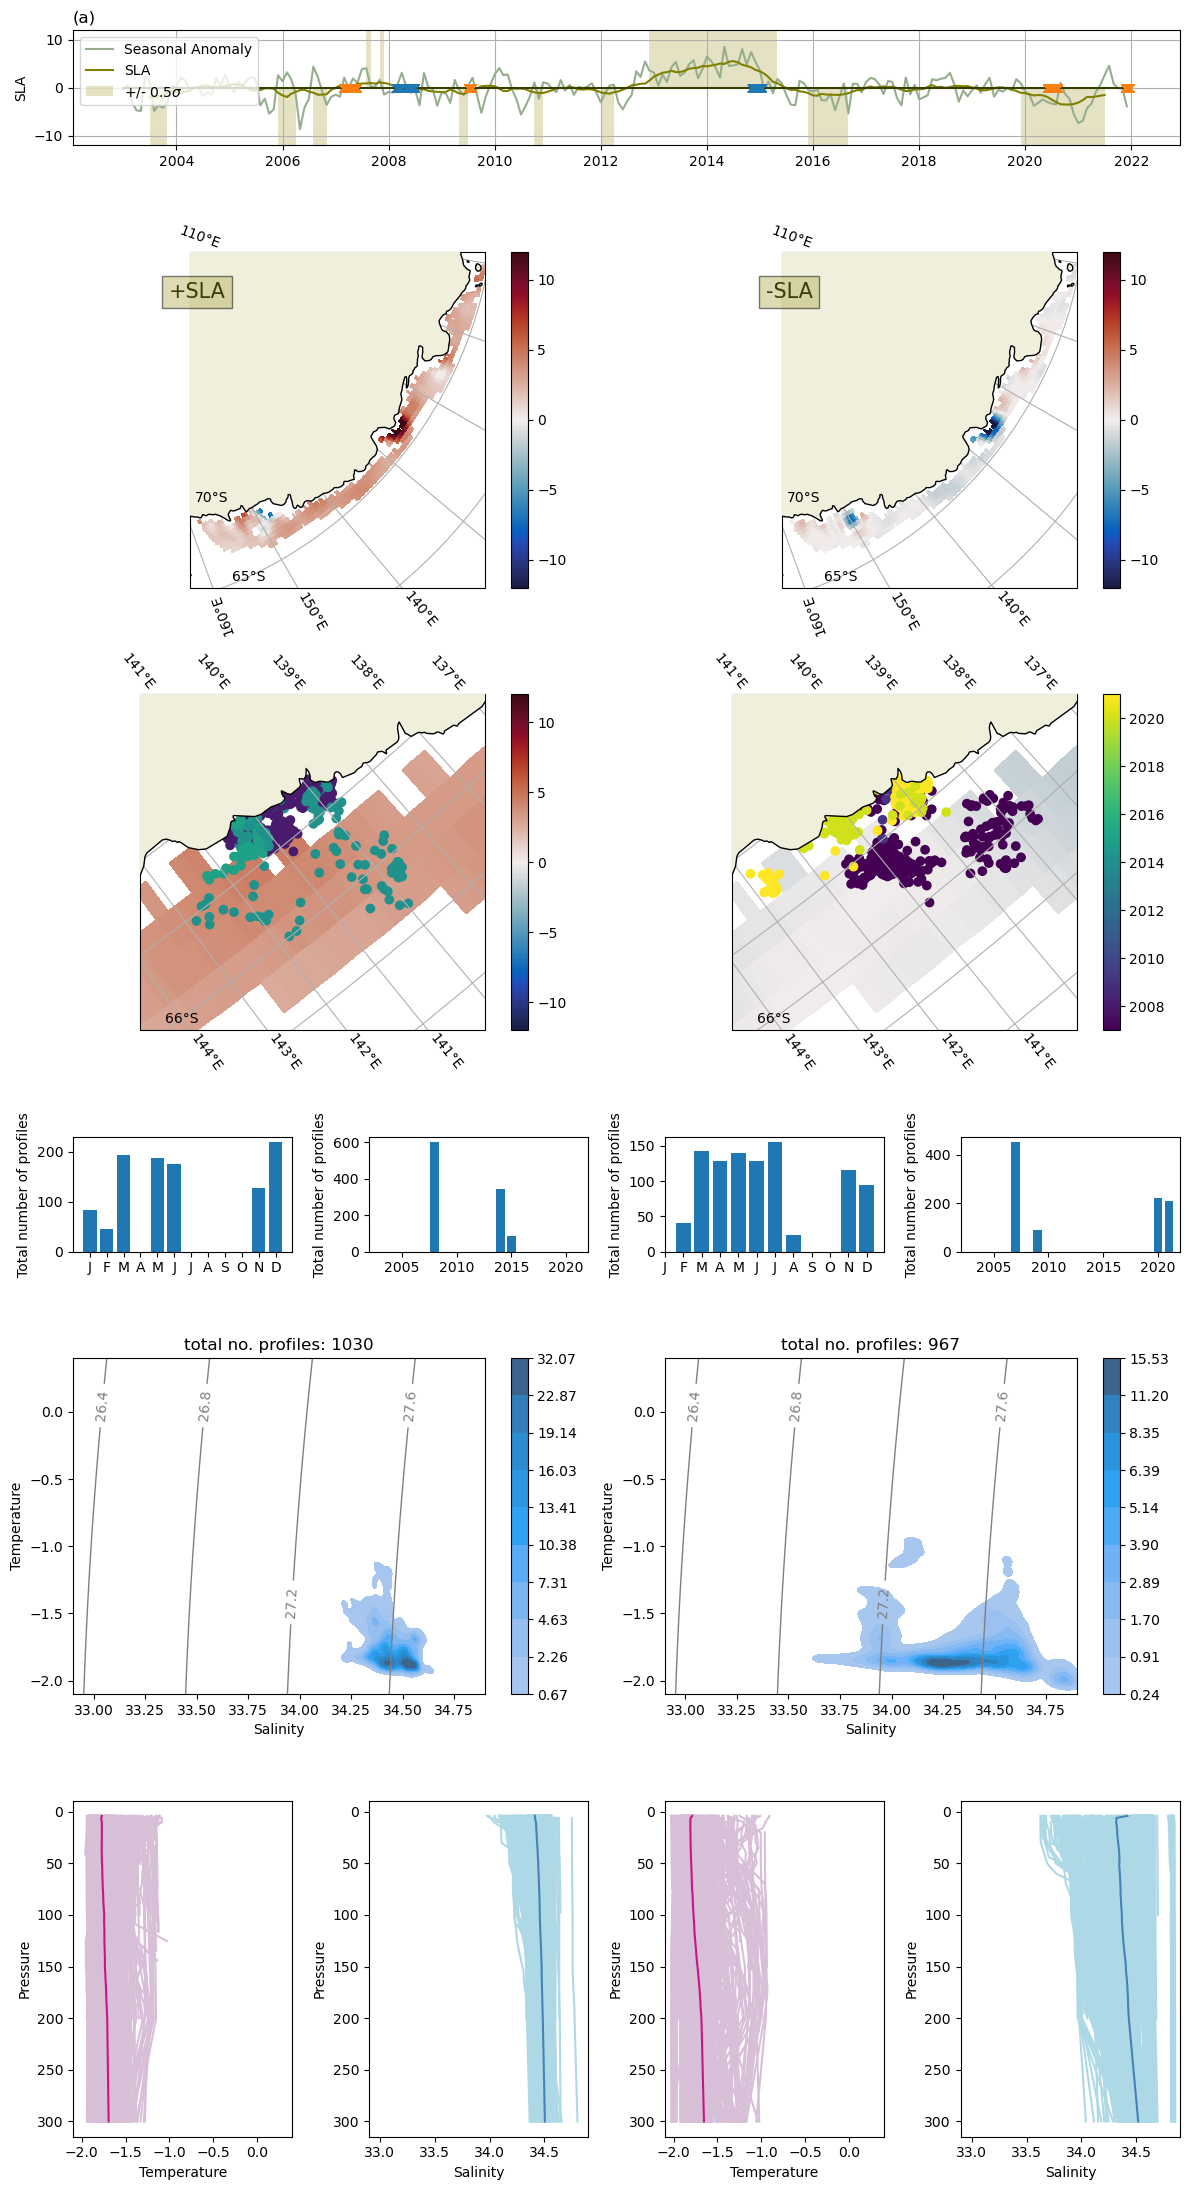

In [ ]:
fig = plt.figure(figsize=(12,22))
gs = fig.add_gridspec(10,4)

# FIG1: SLA/SAM TIMESERIES
ax1 = fig.add_subplot(gs[0, :])

cmp.composite_timeseries(ax1,background_data,bg_name='Seasonal Anomaly')
# FIG2: SLA MAP
ax2 = fig.add_subplot(gs[1:3, 0:2],projection=ccrs.SouthPolarStereo())
ax3 = fig.add_subplot(gs[1:3, 2:4],projection=ccrs.SouthPolarStereo())
cmp.posneg_map([ax2,ax3],sanom(shelf.crop_da(sla)),'SLA',12,extent,label_loc=[130,-80])

# FIG3: SLA closeup
ax4 = fig.add_subplot(gs[3:5, 0:2],projection=ccrs.SouthPolarStereo())
ax5 = fig.add_subplot(gs[3:5, 2:4],projection=ccrs.SouthPolarStereo())
cmp.posneg_map([ax4,ax5],sanom(shelf.crop_da(sla)),'SLA',12,extent_mertz,add_profiles=True)

n = 5
cmp.ts_freq_plot([ 
    fig.add_subplot(gs[n,0]),
    fig.add_subplot(gs[n,1]),
    fig.add_subplot(gs[n,2]),
    fig.add_subplot(gs[n,3]),
])

# FIG4: TS DESNITY
n = 6
cmp.ts_density([
    fig.add_subplot(gs[n:n+2,0:2]),
    fig.add_subplot(gs[n:n+2,2:4])
    ])

# FIG5: TS PROFILES
n = 8
ax8 = fig.add_subplot(gs[8:10,0])
ax9 = fig.add_subplot(gs[8:10,1])
ax10 = fig.add_subplot(gs[8:10,2])
ax11 = fig.add_subplot(gs[8:10,3])
cmp.ts_profiles([ax8,ax9,ax10,ax11])

plt.tight_layout()



In [18]:
tm_pos,p_pos = np.meshgrid(cmp.t_pos.time,cmp.t_pos.pressure)
tm_neg,p_neg = np.meshgrid(cmp.t_neg.time,cmp.t_neg.pressure)
p_pos = p_pos.flatten()
p_neg=p_neg.flatten()
tm_pos = tm_pos.flatten()
tm_neg = tm_neg.flatten()
rho_pos = gsw.density.sigma0(cmp.s_pos.values,cmp.t_pos.values).flatten()
rho_neg = gsw.density.sigma0(cmp.s_neg.values,cmp.t_neg.values).flatten()

In [22]:
sns_data = pd.DataFrame(data={'time':np.concatenate([tm_pos,tm_neg]),
                              'temperature':np.concatenate([cmp.t_pos.values.flatten(),cmp.t_neg.values.flatten()]),
                              'salinity':np.concatenate([cmp.s_pos.values.flatten(),cmp.s_neg.values.flatten()]),
                              'pressure':-np.concatenate([p_pos,p_neg]),
                              'potential density': np.concatenate([rho_pos,rho_neg]),
                              'SLA': ['+ SLA' for _ in tm_pos] + ['- SLA' for _ in tm_neg],
                              'month': get_month(np.concatenate([tm_pos,tm_neg])),
                              'year': pd.to_datetime(np.concatenate([tm_pos,tm_neg])).year
                              })

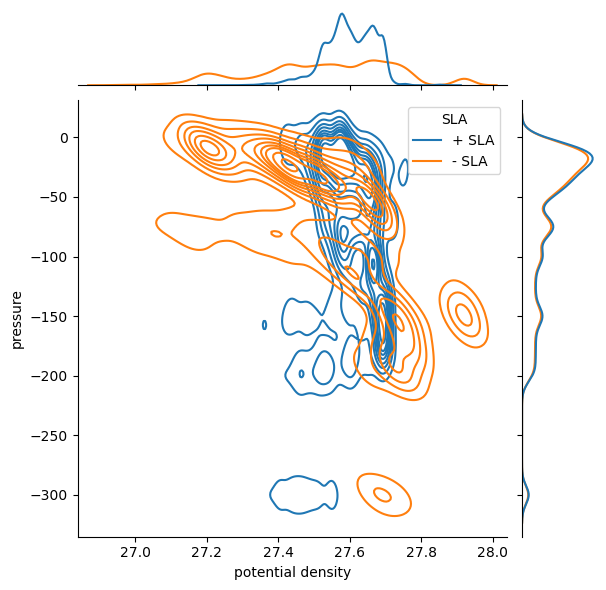

In [23]:
g = sns.JointGrid(data=sns_data, x='potential density', y ='pressure', hue='SLA')
g.plot(sns.kdeplot, sns.kdeplot)

In [24]:
background_data = sanom(sla_shelf).mean(['latitude','longitude'])
background_data = utls.detrend_dim(background_data,'time')
idx_data = background_data.rolling(time=12,center=True).mean('time')

cmp = Composite(idx_data,'SLA')
cmp.add_meop(meop_mertz,tlims=tlims,slims=slims,lag=2)

reindexing temps..
reindexing psals...
merging...
reindexing temps..
reindexing psals...
merging...


In [26]:
tm_pos,p_pos = np.meshgrid(cmp.t_pos.time,cmp.t_pos.pressure)
tm_neg,p_neg = np.meshgrid(cmp.t_neg.time,cmp.t_neg.pressure)
p_pos = p_pos.flatten()
p_neg=p_neg.flatten()
tm_pos = tm_pos.flatten()
tm_neg = tm_neg.flatten()
rho_pos = gsw.density.sigma0(cmp.s_pos.values,cmp.t_pos.values).flatten()
rho_neg = gsw.density.sigma0(cmp.s_neg.values,cmp.t_neg.values).flatten()
ssn_pos = [get_season(t) for t in tm_pos]
ssn_neg = [get_season(t) for t in tm_neg]

In [27]:
sns_data = pd.DataFrame(data={'time':np.concatenate([tm_pos,tm_neg]),
                              'temperature':np.concatenate([cmp.t_pos.values.flatten(),cmp.t_neg.values.flatten()]),
                              'salinity':np.concatenate([cmp.s_pos.values.flatten(),cmp.s_neg.values.flatten()]),
                              'pressure':-np.concatenate([p_pos,p_neg]),
                              'potential density': np.concatenate([rho_pos,rho_neg]),
                              'SLA': ['+ SLA' for _ in tm_pos] + ['- SLA' for _ in tm_neg],
                              'month': get_month(np.concatenate([tm_pos,tm_neg])),
                              'year': pd.to_datetime(np.concatenate([tm_pos,tm_neg])).year
                              })

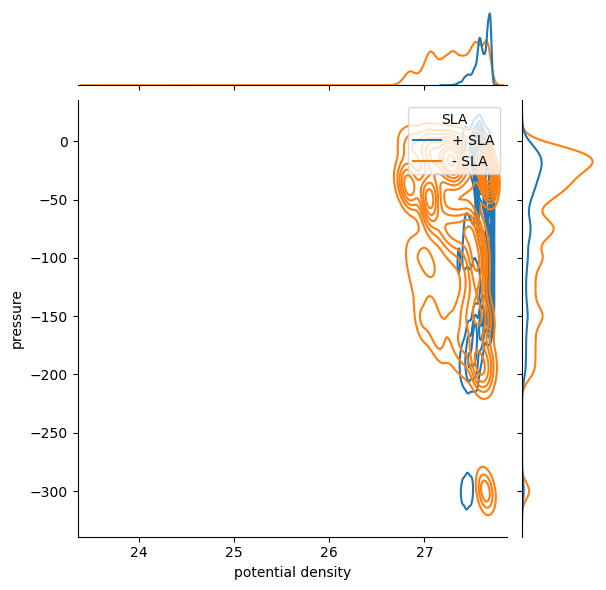

In [28]:
g = sns.JointGrid(data=sns_data, x='potential density', y ='pressure', hue='SLA')
g.plot(sns.kdeplot, sns.kdeplot)

In [29]:
background_data = sanom(sla_shelf).mean(['latitude','longitude'])
background_data = utls.detrend_dim(background_data,'time')
idx_data = background_data.rolling(time=12,center=True).mean('time')

cmp = Composite(idx_data,'SLA')
cmp.add_meop(meop_mertz,tlims=tlims,slims=slims,lag=3)
tm_pos,p_pos = np.meshgrid(cmp.t_pos.time,cmp.t_pos.pressure)
tm_neg,p_neg = np.meshgrid(cmp.t_neg.time,cmp.t_neg.pressure)
p_pos = p_pos.flatten()
p_neg=p_neg.flatten()
tm_pos = tm_pos.flatten()
tm_neg = tm_neg.flatten()
rho_pos = gsw.density.sigma0(cmp.s_pos.values,cmp.t_pos.values).flatten()
rho_neg = gsw.density.sigma0(cmp.s_neg.values,cmp.t_neg.values).flatten()
ssn_pos = [get_season(t) for t in tm_pos]
ssn_neg = [get_season(t) for t in tm_neg]
sns_data = pd.DataFrame(data={'time':np.concatenate([tm_pos,tm_neg]),
                              'temperature':np.concatenate([cmp.t_pos.values.flatten(),cmp.t_neg.values.flatten()]),
                              'salinity':np.concatenate([cmp.s_pos.values.flatten(),cmp.s_neg.values.flatten()]),
                              'pressure':-np.concatenate([p_pos,p_neg]),
                              'potential density': np.concatenate([rho_pos,rho_neg]),
                              'SLA': ['+ SLA' for _ in tm_pos] + ['- SLA' for _ in tm_neg],
                              'month': get_month(np.concatenate([tm_pos,tm_neg])),
                              'year': pd.to_datetime(np.concatenate([tm_pos,tm_neg])).year
                              })

reindexing temps..
reindexing psals...
merging...
reindexing temps..
reindexing psals...
merging...


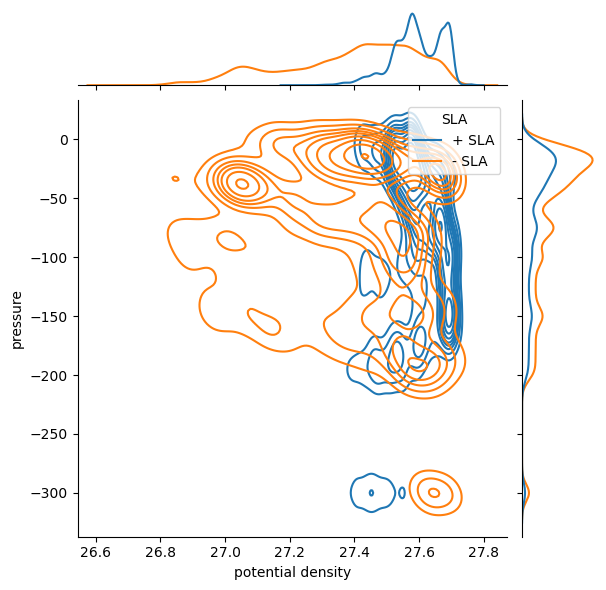

In [30]:
g = sns.JointGrid(data=sns_data, x='potential density', y ='pressure', hue='SLA')
g.plot(sns.kdeplot, sns.kdeplot)